<a href="https://colab.research.google.com/github/Aurecc/PCA-Logistic-Regression-from-scratch/blob/main/PCA%20%26%20Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principal Component Analysis and Logistic Regression. Behind the scenes.

If you are reading this project you might already know what does a PCA or Principal Component Analysis is and perhaps when is it a good time to use it. You might also know what sort of problem is to be solved with a Logistic Regression and even how to program both algorithms and fit your data with them.

However, here we are going to learn how both these algorithms work by making them from scratch. No Scikit-Learn here. What is a Covariance Matrix? How should I prepare the data? Eigen what? Why should I descend a gradient? These are some of the questions that are to be answered in the following chapters. So if you are curious enough to follow, learn or remember how thes algorithms work in detail, this is certainly your place.

The Dataset to be used for this project is the [Default of Credit Card Clients
](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients) from UC Irvine's Machine Learning Repository. This dataset is a great example where both of the models have great potential. Without further a do, let us import the data and start to work.

In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

In [4]:
# Show the first 5 rows of data
variables = list(default_of_credit_card_clients.variables['description'])[1:]
map_X = dict(zip(X.columns,variables))

X = X.rename(columns=map_X)
y = y.rename(columns={'Y':'default'})

X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


# Variables

The target is a binary variable, default payment (Yes = 1, No = 0). The following 23 variables are the explanatory variables:


- LIMIT_BAL: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.

- SEX: Gender (1 = male; 2 = female).

- EDUCATION: Education level (1 = graduate school; 2 = university; 3 = high school; 4 = others).

- MARRIAGE: Marital status (1 = married; 2 = single; 3 = divorce; 0=others).

- AGE: Age (year).

- PAY_0 - PAY_6: History of past monthly payment records (from April to September, 2005) as follows: PAY_0 = the repayment status in September, 2005; PAY_1 = the repayment status in August, 2005; . . .;PAY_6 = the repayment status in April, 2005.

The measurement scale for the repayment status is:

-2: No consumption; -1: Paid in full; 0: The use of revolving credit; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.

- BILL_AMT1-BILL_AMT6: Amount of bill statement (NT dollar). BILL_AMT1 = amount of bill statement in September, 2005; BILL_AMT2 = amount of bill statement in August, 2005; . . .; BILL_AMT6 = amount of bill statement in April, 2005.

- PAY_AMT1-PAY_AMT6: Amount of previous payment (NT dollar). PAY_AMT1 = amount paid in September, 2005; PAY_AMT2 = amount paid in August, 2005; . . .;PAY_AMT6 = amount paid in April, 2005.

At first glance, the target variable is binary, meaning it is a classification problem with two outcomes. There are many models that can fit this data, specifically a Logistic Regression. Another remarkable trait of this dataset is the amount of variables it presents, more than twenty! This presents also a great opportunity to perform a Feature extraction with a PCA. The main goal is to fit a PCA to find the components that explain the majority of the variance in the data. After finding said components, they will be used as explanatory features to predict via Logistic Regression the target variable.



https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/discussion/34608


## Exploration

The first step involves exploring the data. This is a basic step, but a necessary one to understand the data, what can it be done with it, learn their flaws, skewness and inconsistencies and of course, to make our assumptions before jumping to the models.

We will start by showing the summary statistics:

In [5]:
cat = ['SEX', 'EDUCATION', 'MARRIAGE']
pay = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill = ['BILL_AMT1', 'BILL_AMT2','BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt = ['PAY_AMT1','PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

In [6]:
X[cat].describe()

,SEX,EDUCATION,MARRIAGE
count,30000.000000,30000.000000,30000.000000
mean,1.603733,1.853133,1.551867
std,0.489129,0.790349,0.521970
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000
75%,2.000000,2.000000,2.000000
max,2.000000,6.000000,3.000000


It seems the EDUCATION column has values that are out of the categories. The rest of categorical variables seem as intended.

In [7]:
proportion_null = X[X['EDUCATION']>4]['EDUCATION'].count()/X['EDUCATION'].count()*100
print(f'Proportion of out of category values: {proportion_null: .2f}%')

Proportion of out of category values:  1.10%


There are not so many of these values in the dataset. Given there is an "other" category, those values will be included as such as there is no further information given from the original researchers.

In [8]:
X[pay].describe()

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100
std,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000


The PAY status variables do not present any anomaly. A further exploration will take place where we will see distributions.

In [9]:
X[bill].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400
std,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


In [10]:
X[pay_amt].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


Bill and Pay amount variables seem to be skewed over higher values as the means is greater than medians. This is because monetary values tend to scale rapidly with higher aquisition power. Let us observe the distribution of the target.

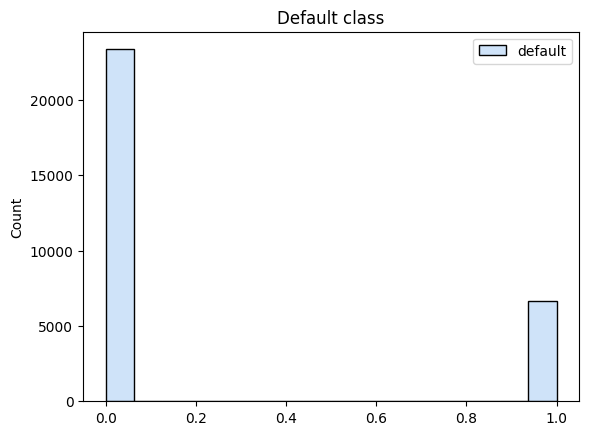

In [11]:
sns.set_palette('pastel')
sns.histplot(y)
plt.title('Default class')
plt.show()

There is quite a problem of class balance of the target. This behaviour is normal in this situation as defaults are usually unlikely to happen. There are some ways to deal with this inbalance, for instance, the final Logistic Model can be tweaked to higher recall, or we could balance the data sinthetically by oversampling.

This last approach duplicates random observations of the minority class (in this case, those who defaulted) until the target variable is balanced. If done correctly, the final model would classify more acurately reducing bias, but it could also lead to overfitting if there are too many copies of an observation.

### Distributions

The following histograms shows the data distributions individually.

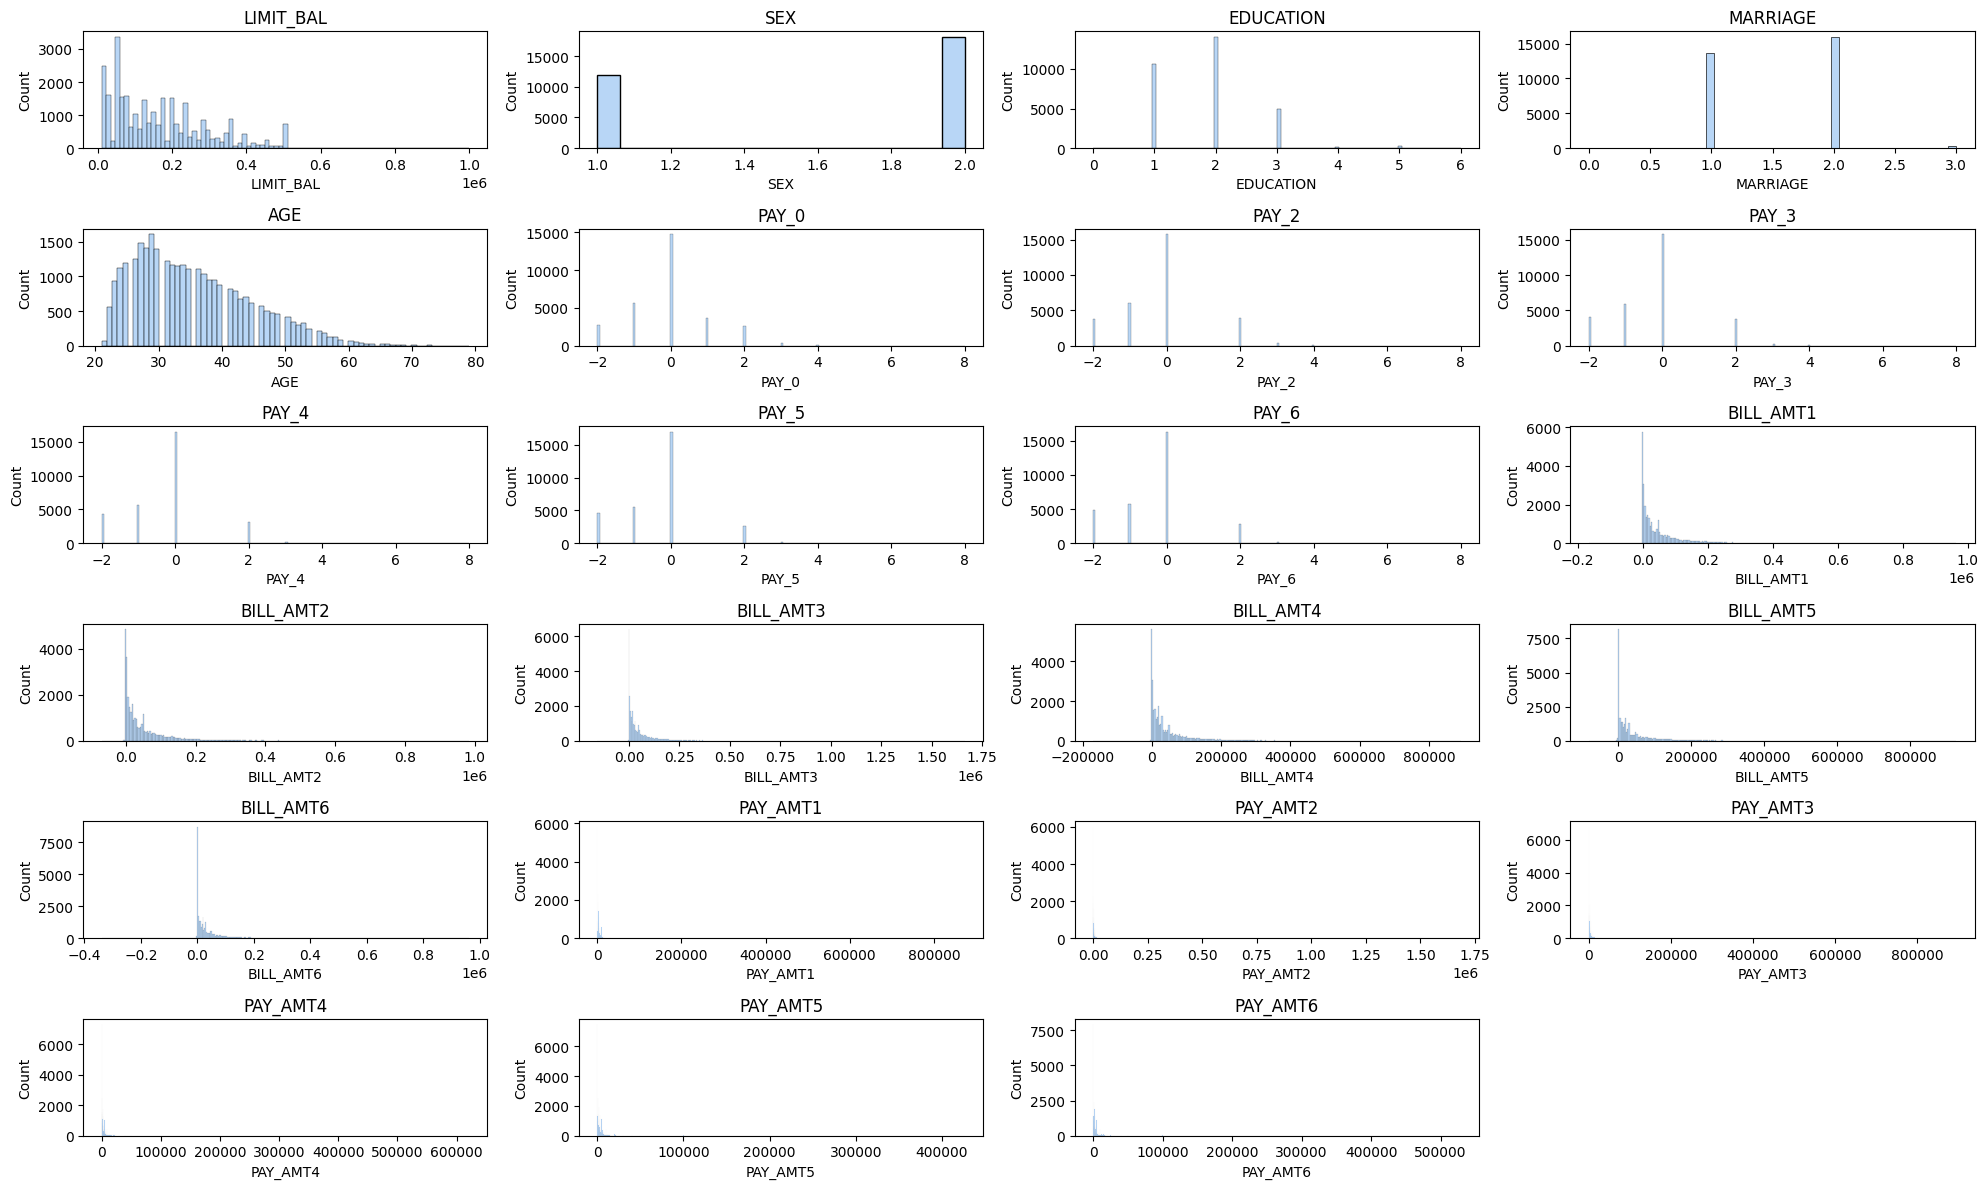

In [12]:
def show_histograms(data):
    fig, axes = plt.subplots(nrows=6,ncols=4, figsize= (20,12))
    flat_axes = axes.flatten()
    for idx, column in enumerate(data.columns):
      sns.histplot(ax= flat_axes[idx],data= data,  x = column)
      flat_axes[idx].set_title(column)



      for idx in range(len(data.columns),len(flat_axes)):
          flat_axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

show_histograms(X)

It is quite clear there are many skewed variables towards higher values, primarily those that are monetary. These variables are to be furtherly transformed and scaled logarithmically. This way we could make their distributions pseudo-normal and thus, linearly related to the target variable.

Next it is needed to observe how these variables are correlated to each other. The goal is to ascertain if there is multicolinearity or if every variable in this dataset has a unique explanation of the variance of the target.

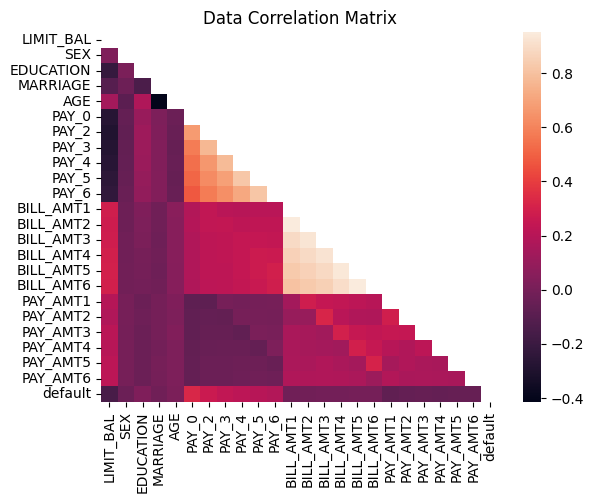

In [13]:
df = X.copy()
df['default'] = y
mask = np.triu(np.ones_like(df.corr()))
sns.heatmap(df.corr(), mask = mask)
plt.title('Data Correlation Matrix')
plt.show()

Some variables are highly correlated with other explanatory variables. All BILL_AMT columns show values over 0.8 in correlation. This could present a major issue when predicting an outcome due to noise introduction into the model. If there are many highly correlated variables, the risk of high error or misclassification rises because the model might not understand which variable contributes to the target, thus introducing high variance into it. Mathematically it could also make the data matrix non invertible which could also make the model impossible to train.

There are some ways to decrease the multicolinearity in the data. A simple approach is to drop some columns arbitrarily or by Feature Selection. Another approach, the one to be applied in this project is Feature Extraction via Principal Component Analysis. This method calculates a covariance matrix that registers the variance and direction of all variables to then find the $k$ principal components or combination of variables that uniquely explains the variability of the data. This principal components will be a new set of uncorrelated variables that will feed the classification model.

But before that, let us check how is the target related with respect other data.

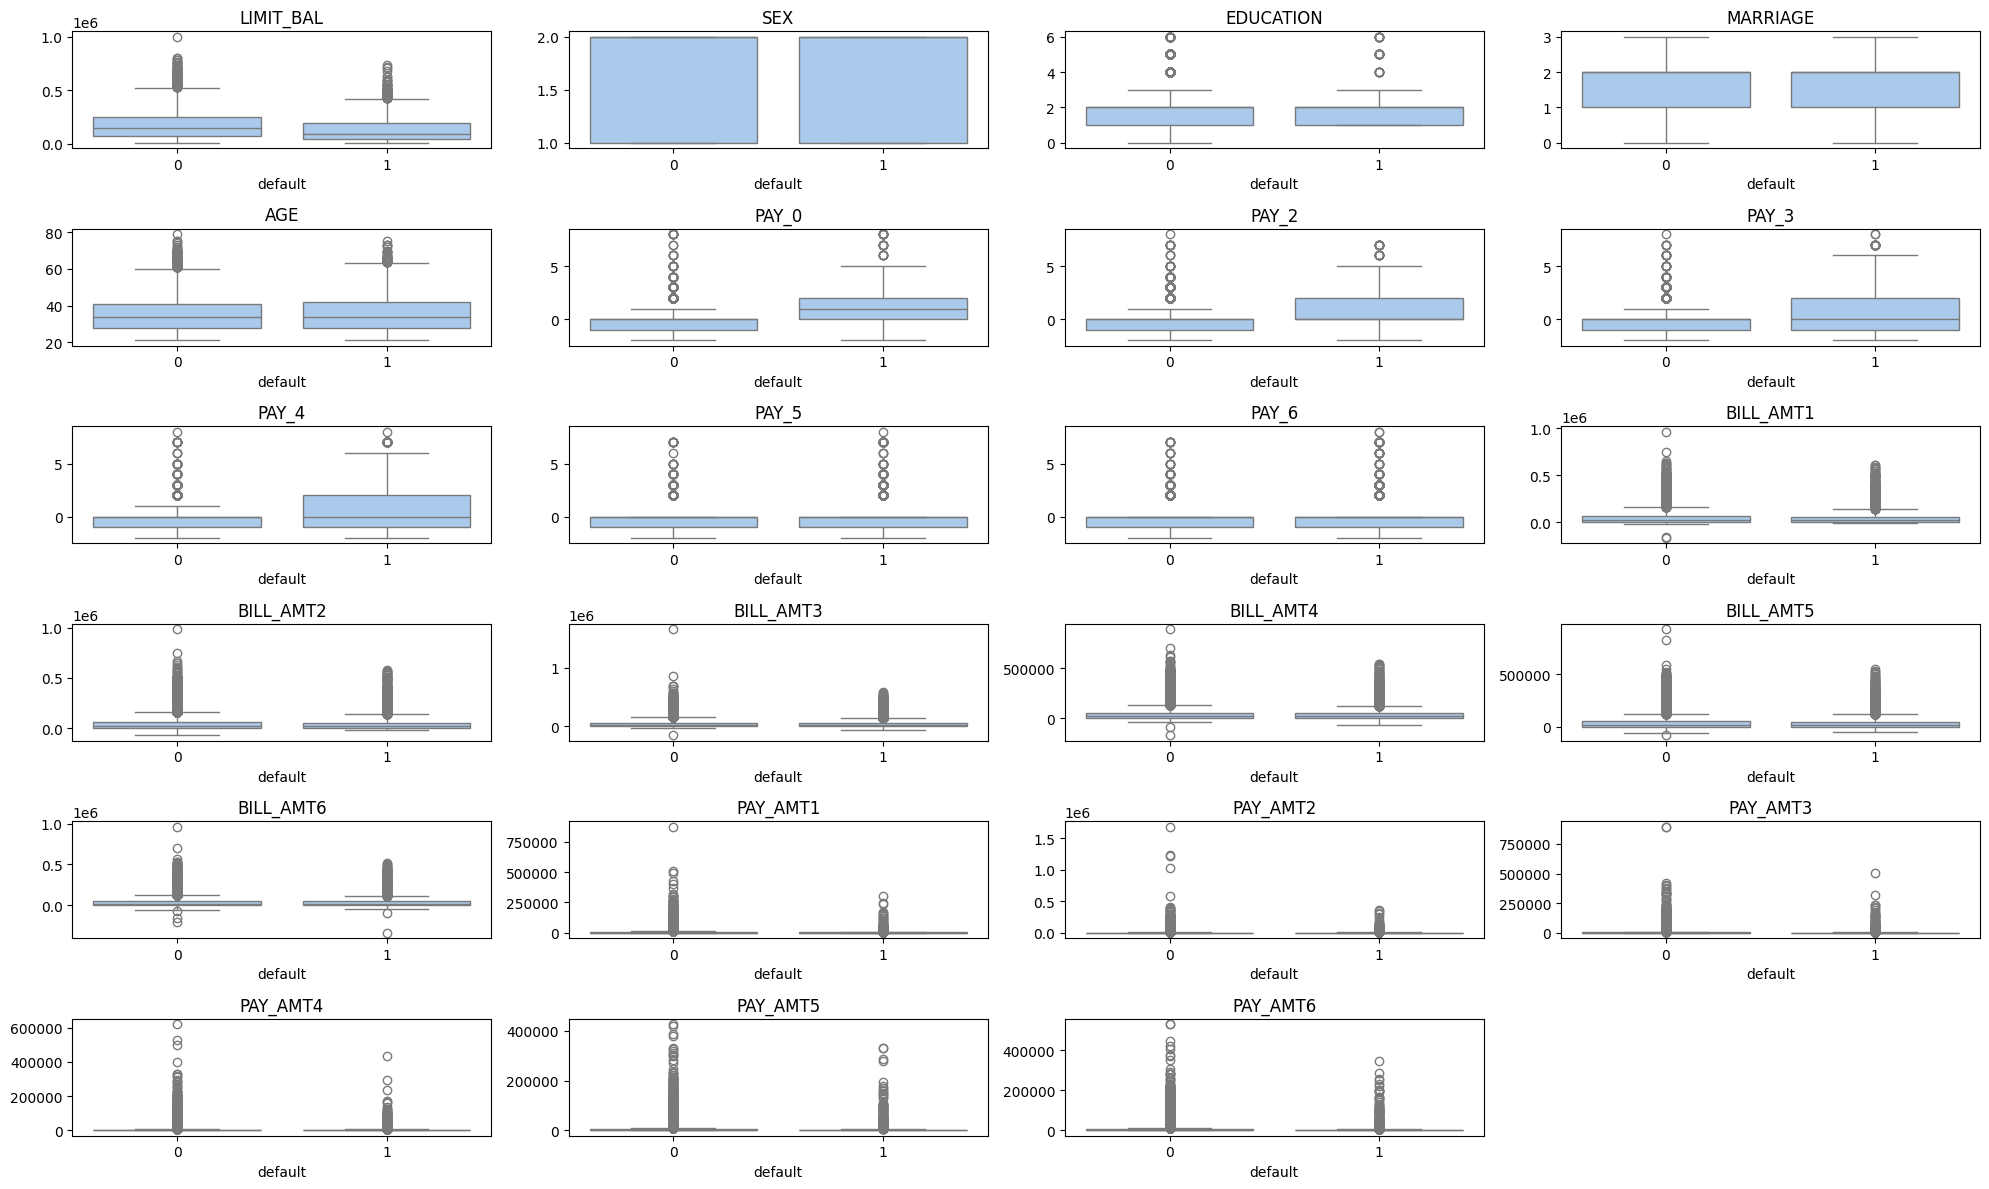

In [14]:
def show_boxplots(data, target):
    fig, axes = plt.subplots(nrows=6,ncols=4, figsize= (20,12))
    flat_axes = axes.flatten()
    for idx, column in enumerate(data.columns):
          sns.boxplot(ax = flat_axes[idx],data = df,x=target,y=column)
          flat_axes[idx].set_title(column)
          flat_axes[idx].set_ylabel('')



          for idx in range(len(data.columns),len(flat_axes)):
              flat_axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

show_boxplots(X,y['default'])

Pay status seem to be highly correlated with the target. Meaning that delays on payment could be related with a possible default from a client. Other variables do not seem to be visually related to the target

# Transformation

After initial exploration, now it is time to transform the data in order to fit the models. First we start with the Categorical Variables by distinguishing each one of them.

- Gender: In this dataset is a binary variable (1 = male; 2 = female). The only transformation for this variable will be to subtract 1 to make the column range into 0 and 1. It is not strictly necessary do make this minor transformation, but it will add consistency with the rest of the dataset.

- Education and Marital status: given that the categories in these variables are ordinal, the values must be ordered by a level. In this case. 1 = graduate school; 2 = university; 3 = high school; 4 = others in the case of Education and 1 = married; 2 = single; 3 = divorce; 0=others for Marital status. Therefore the applying change will be to sort the categories order accordingly.

In [15]:
X['SEX'] = X['SEX']-1

education_map = {3:2, 2:3}
X['EDUCATION'] = X['EDUCATION'].apply(lambda x: 4 if x >4 else x)
X['EDUCATION']= X['EDUCATION'].map(education_map).fillna(X['EDUCATION'])

In [16]:
marital_map = {2:1, 1:2}

X['MARRIAGE'] = X['MARRIAGE'].map(marital_map).fillna(X['MARRIAGE'])

### Logarithmic transformation of Numerical variables

As some numerical variables distributions are skewed towards the right it is necessary to transform their values so the distributions become closer to a Gaussian distribution to prevent skewness in the next standarization.

The transformation function is as follows:

$$log(x)= sign(x)× log(|x|+1)$$

where $x$ is a value of variable from the Dataset.

The code to applying Logarithmic transformation the following

In [17]:
def log_transform(x):
  return np.sign(x) * np.log10(np.abs(x) + 1)

num_columns = ['LIMIT_BAL','AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

for col in num_columns:
  X[col] = X[col].apply(lambda x: log_transform(x))

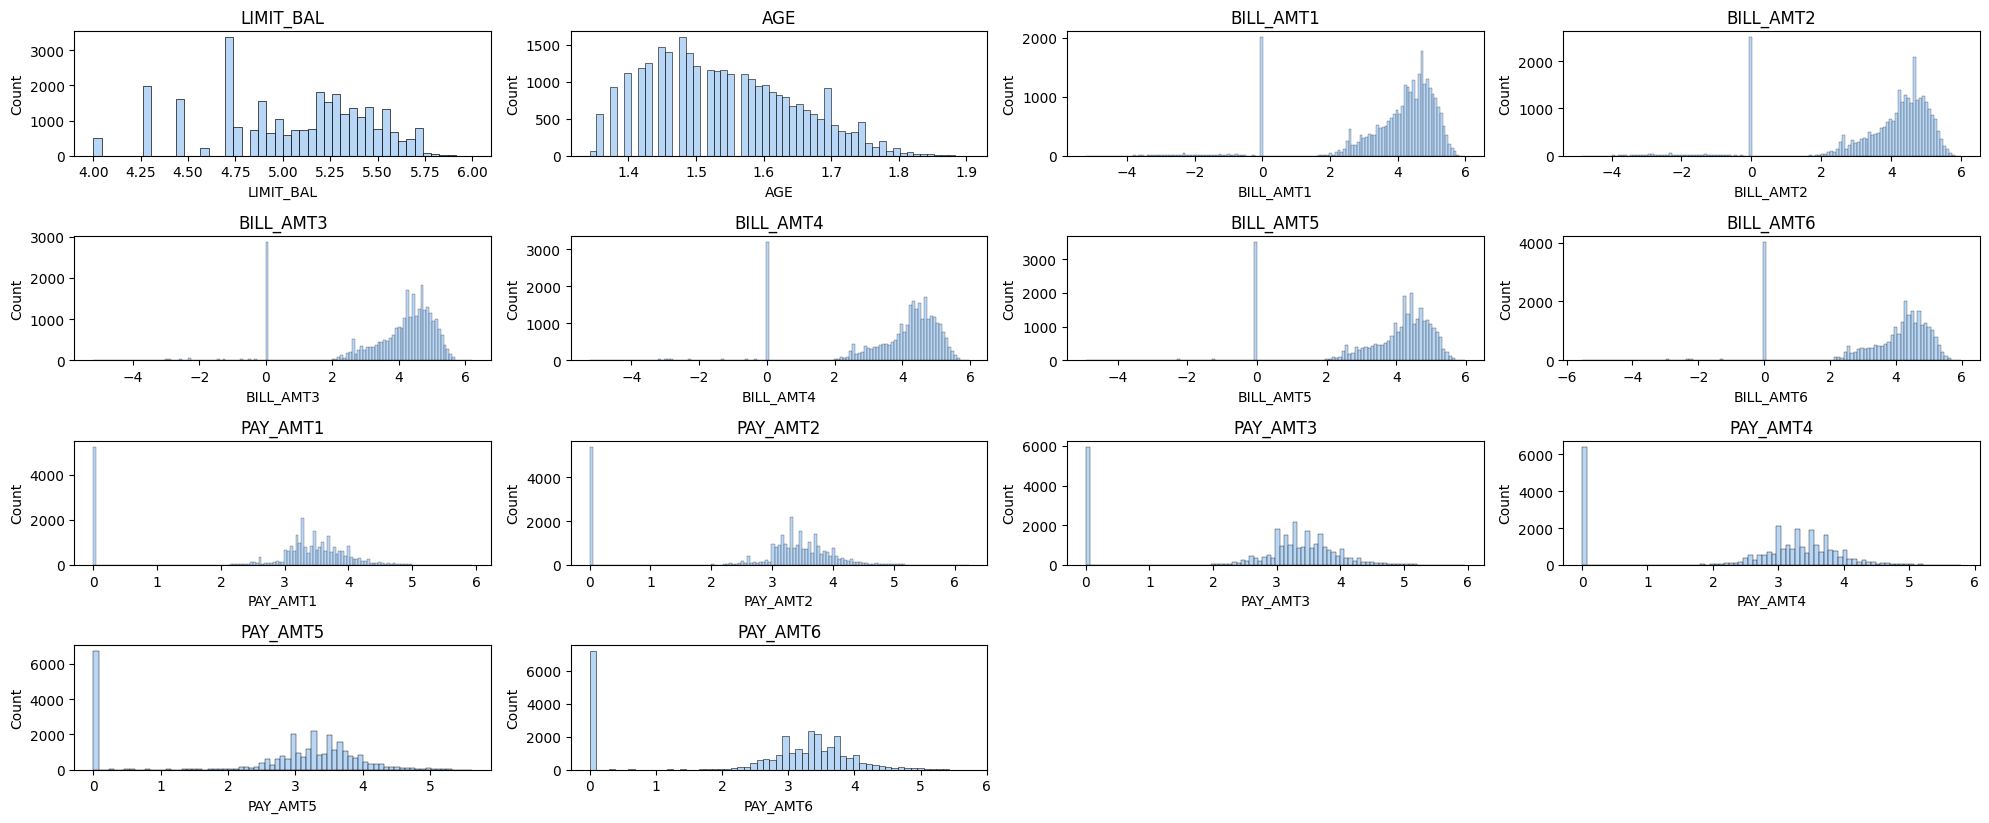

In [18]:
show_histograms(X[num_columns])

The immediate results are obvious. The skewness is mostly gone and the distributions are now quite simmetrical. It is worth to notice that the Amount variables (BILL_AMT and PAY_AMT) have a high count of zeros that could make a distribution on its own. This represents a great opportunity to get further information from the data and flag those variables. The way it will be performed is by creating a boolean column for each Amount variable where if the original value is zero, the flag will be set in TRUE (or 1 in this case).  



In [19]:
Amount_Columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5',
                  'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
                  'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

for col in Amount_Columns:
  X[f'{col}_is_zero'] = (df[col]==0).astype(int)

Last but not least. Before training any model it is needed to split our data in two sets: one for training and one for test. The purpose is to fit the model with the training set and evaluate the trained model with the test set. Thus it is imperative to separate those sets before scaling, as the test set should remain isolated from the any transformation that requires any summary statistic such as mean or variance, to prevent any data leakage that could contaminate the test, making us believe the model is better than it is.  

A better approach is to use another validation set (or more than one set) before the final test for a better evaluation. But this scope is out of the current project.

With this last step the transformation process is finished. Now we can continue with the main goal of this project. Next we are performing the Principal Component Analysis.

# Principal Components Analysis

A PCA is an unsupervised Machine Learning model where the goal is to extract new features from the original variables. The way a PCA works is by computing the variances in the whole dataset and then finding and selecting the $k$ components or variables combination that explain a set proportion of the captured variance (In this case, 90%).

There are 3 main steps in this process:

- Covariance Matrix: The first step involves computing the variances and covariances of our dataset and register them in a Covariance Matrix.

- Finding the Eigenvalues and Eigenvectors of the Covariance Matrix. In this step it is required to transform the matrix to compute the Eigenvalues and Eigenvectors. these two objects explains which components are the most important in terms of Data variance and which variables contribute more or less into each component. These components can be then interpreted and it will be possible to find a new underlying variable from every component.

- Projecting the Eigenvectors into the Dataset. By multiplying the original Dataset with the resulted Eigenvectors, we will have a new matrix or a new dataset ready to fit the classifier.

## Covariance Matrix
The first step to perform a Principal Components Analysis is to find the Covariance matrix of our dataset. This step is crucial because this matrix registers the variances and covariances of the dataset which allows to see which variables are those that explain the variability of the data.

Given an $X$ matrix with size $n\times m$ the Covariance Matrix of X is computed as follows:

$$Cov(X)= \frac{1}{n-1}(X- \bar{X})^T(X- \bar{X})$$

The resulting matrix should have a shape as follows:

$$Cov(X)= \begin{equation}
\begin{pmatrix}
\sigma^2(x_{1}) & cov(x_{1},x_{2})&... & cov(x_1, x_m)\\
cov(x_{2},x_{1}) & \sigma^2(x_{2}) & \cdots & cov(x_2, x_m)\\
\vdots & \vdots & \ddots & \vdots\\
cov(x_{m},x_{1}) & cov(x_{m},x_{2}) & &\sigma^2(x_{m})
\end{pmatrix}
\end{equation}$$

## Finding the Eigenvalues and Eigenvectors

In order to do a Principal Component Analysis we will need to find the principal axes of our data. These axes are basically the Eigenvectors, which gives us a hint of the direction of this axes and the Eigenvalues, which give us a hint of the importance of that vector. To find these components it will be needed to transform our $A$ Covariance Matrix so that

$$Av=λv$$

Where $λ$ is the Eigenvalue and $v$ is the Eigenvector. Each Eigenvector is Orthogonal and linearly independent of each other, meaning that each axis captures unique information that explains the data variation.

### Jacobi Method

The numerical method to be used to compute these Eigenvalues and Eigenvectors is the Jacobi Method. This method requires a symmetric matrix (such as our covariance matrix) and makes orthogonal rotations using the largest absolute values of the non-diagonal elements of the matrix. For instance: given the matrix $A$ with highest absolute value is $A_{pq} $ and $p$ is different from $q$ (not in the diagonal) the rotation angle

$$tan(2θ)= \frac{2A_{pq}}{A_{pp}-A_{qq}}$$
$$\theta = \frac{1}{2}arctan(\frac{2A_{pq}}{A_{pp}-A_{qq}})$$

to avoid dividing by zero, if $A_{pp} = A_{qq}$ we set $\theta = \frac{π}{4}$

The next step involves constructing the matrix $P$. This is an Identity Matrix where the elements at position $(p,p)$ and $(q,q)$ are replaced by $cos(\theta)$; the element at $(p,q)$ by $-sin(\theta)$ and the element at $(q,p)$ by $sin(\theta)$. After making this changes the rotation shall be performed as follows:

$$A_{new} = P^TAP$$

This process is repeated until all non diagonal elements of the $A$ are zero or close enough to zero. The resulting diagonal elements are the Eigenvalues.

At the same time, the Eigenvectors are computed and accumulated during these iterations as follows:

$$V_{new} = VP $$ where $V$ is initialized as an Identity matrix $V^{(1)}$.

## Feature importance and direction.

After finding these eigenvalues and eigenvectors we can find the principal Components that explain the data variation. The sum of the Eigenvalues is the total variance of the data explained by this components and each Eigenvalue explain a proportion of this variance. The standard approach is to select the $k$ components that explain an arbitrary proportion of said variance (normally more than 70%).

Each Eigenvalue has an Eigenvector associated with it. This Eigenvector constitute the direction where each variable is moving towards. The higher the absolute value, the higher the importance of the variable within the component. This importance is called loadings and they are crucial to know which features of our data explain most of the variance.

Finally, in order to use the Principal Components for further analysis or modelling it will be needed to project our original centered data as follows:

$$PC = (X- \bar{X})V$$ where $V$ is the EigenVector's Matrix.



In [20]:
class PCA_from_scratch:
  def __init__(self,n_components):
     self.n_components = n_components
     self.components = None
     self.means = None
     self.explained_variance = None
     self.cum_variance = None

  def covariance_matrix(self, X):
    X = X.to_numpy()
    self.means = np.mean(X, axis=0)
    X_center = X -self.means
    n = X.shape[0]-1
    cov = (1/n) * (X_center.T @ X_center)
    return cov

  def jacobi_eigenvalues(self,X, tol = 1e-9, max_iter=1000):

    A = self.covariance_matrix(X)
    n = A.shape[0]

    V = np.eye(n)

    for i in range(max_iter):
      A_triu = np.triu(np.abs(A), k=1)

      p,q = np.unravel_index(np.argmax(A_triu), A.shape)

      if A_triu[p,q] < tol:
        break

      if A[p,p] == A[q,q]:
        theta = np.pi/4
      else:
        theta = 0.5 * np.arctan(2 *A[p,q]/ (A[p,p]-A[q,q]))

      c = np.cos(theta)
      s = np.sin(theta)

      P = np.eye(n)
      P[p,p] = c
      P[q,q] = c
      P[p,q] = -s
      P[q,p] = s

      A = np.dot(P.T, np.dot(A,P))
      V = np.dot(V,P)

    eigenvalues = np.diag(A)
    eigenvectors = V
    idxs = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idxs]
    eigenvectors = eigenvectors[:,idxs]

    return eigenvalues, eigenvectors


  def fit(self, X):

    eigenvalues, eigenvectors = self.jacobi_eigenvalues(X)

    total_variance = np.sum(eigenvalues)
    explained_variance = eigenvalues/ total_variance
    cum_variance = np.cumsum(explained_variance)

    self.components = eigenvectors[:, :self.n_components]
    self.explained_variance = explained_variance
    self.cum_variance = cum_variance

  def get_loadings(self,features_names):
    pc_names = [f'PC{i+1}' for i in range(self.n_components)]

    loadings_df = pd.DataFrame(data= self.components, columns=pc_names, index=features_names)
    return loadings_df

  def transform(self, X):
    X = X.to_numpy()
    X_center = X - self.means
    return np.dot(X_center, self.components)

  def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

We are done with the Principal Components for now. Next chapter will involve the Logistic Regression and finally, model evaluation.

# Logistic Regression

The second and final model to be applied to this dataset is a Logistic Regression. Knowing we are dealing with a binary classification problem, it is possible to predict (we will see if accurately) if a certain client is about to default on his/her credit card or not.

A Logistic Regression returns a probability value from zero to one using a sigmoid function

$$σ(z) = \frac{1}{1+e^{-z}}$$

where $$z = Xw + b$$

and where $w$ are the weights vector assigned to each variable and $b$ is the bias.

From this sigmoid function  it is possible to calculate a probability of default given certain $w$ weights. Again, as there is no closed-form solution to find $w$ algebraically, we are facing an optimization problem where we need to compute the $w$ that fits best in our data. In other words, it is required to find the $w$ values that minimize the errors or misclassifications. This error can be defined by the cross-entropy function:

$$J(w,b) = -\frac{1}{N} \sum^N_{i=1} [y_ilog(\hat{y}_i) + (1-y_i)log(1-\hat{y}_i)]$$

where:
- $y$ are the actual values in our target data
- $\hat{y}$ are the predicted values
- $N$ is the sample size.

So basically it is an optimization problem where it is required to minimize the cost function $J(w,b)$




For this problem we are also applying an L2 regularization just to avoid overfitting. Our PCA already has regularization properties and manages overfitting because it only chooses components that are most relevant to the model, so e regularization is only an extra precaution.

Cost Function with Ridge Regularization is as follows:

$$J(w) = -\frac{1}{N} [y^Tlog(\hat{y}) + (1-y)^Tlog(1-\hat{y})] + \frac{\lambda}{2N}w^Tw$$


To optimize the cost function and find the values of $w$ that satisfy the minimum error it is recommended to break the function in three parts: The cost function stated above, the sigmoid function which is encapsulated in $\hat{y}$

$$\hat{y}=σ(z) = \frac{1}{1+e^{-z}} = (1+ e^{-z})^{-1}$$

 and the linear function $z$.

 $$z = Xw + b$$

Once these functions are defined we can proceed to find the gradient and start the optimization process. First let us find the partial derivative for the cost function:

$$\frac{\partial J}{\partial \hat{y}}= -\frac{1}{N}  (\frac{y}{\hat y} - \frac{1-y}{1- \hat y}) $$

Then we do the same for the sigmoid function:

$$\frac{\partial \hat y}{\partial z} = -1(1+e^{-z})^{-2} \odot (-e^{-z})=(1+e^{-z})^{-2} \odot (e^{-z})=e^{-z} \odot \frac{1}{(1+e^{-z})^2}= \frac{e^{-z}}{(1+e^{-z})^2}= \frac{1}{1+e^{-z}} \odot \frac{e^{-z}}{1+e^{-z}} =\frac{1}{1+e^{-z}}  \odot ( 1 - \frac{1}{1+e^{-z}}) = \sigma(z) \odot (1 -\sigma(z)) = \hat{y} \odot (1- \hat{y}) $$

Note: Proof that:
$$\frac{e^{-z}}{1+e^{-z}}=1+\frac{e^{-z}}{1+e^{-z}}-1=1 + \frac{e^{-z}}{1+e^{-z}} -(\frac{1+e^{-z}}{1+e^{-z}})=1 + (\frac{e^{-z}-1-e^{-z}}{1+e^{-z}})= 1 - \frac{1}{1+e^{-z}}$$

By applying the chain rule of these two derivatives:

$$\frac{\partial J}{\partial z} =\frac{\partial J}{\partial \hat{y}} \odot \frac{\partial \hat y}{\partial z} = -\frac{1}{N}  (\frac{y}{\hat y} - \frac{1-y}{1- \hat y}) \odot (\hat y \odot (1 -\hat y)) = -\frac{1}{N} [(\frac{y}{\hat y}\odot \hat y \odot (1-\hat y) -( \frac{1-y}{1-\hat y }\odot \hat y \odot (1-\hat y) ] = -\frac{1}{N} [y \odot (1- \hat y)-(1-y)\odot \hat y] =-\frac{1}{N} [y - y \odot \hat y - \hat y + y \odot \hat y] = -\frac{1}{N} [y - \hat y] = \frac{1}{N}(\hat y - y)$$

Finally, the partial derivatives for $z$:
$$\frac{\partial z}{\partial w} = X $$
$$\frac{\partial z}{\partial b} = 1 $$

In summary:
$$\frac{\partial J}{\partial w}= X^T\frac{\partial J}{\partial z} + \frac{\lambda}{N}w = \frac{1}{N}X^T(\hat y - y) + \frac{\lambda}{N}w $$

$$\frac{\partial J}{\partial b}= \sum\frac{\partial J}{\partial z} = \sum\frac{1}{N}(\hat y - y)$$

In [21]:
from sklearn.utils import class_weight
class LogisticRegression_scratch():
    def __init__(self, learning_rate = 0.001,n_iter = 1000, lambda_param=0, class_weight = False):
       self.learning_rate = learning_rate
       self.n_iter = n_iter
       self.lambda_param = lambda_param
       self.class_weight = class_weight
       self.w = None
       self.b = None
       self.logloss = None
       self.n_iter_real = None

    def get_class_weights(self,y):

      N = len(y)
      classes = np.unique(y)
      K = len(classes)

      if self.class_weight:
        weights = {}
        for k in classes:
          N_k = np.sum(y==k)
          weights[k]= N/(K*N_k)


      else:
        weights =  {k:1 for k in classes}

      self.class_weight = weights

      sample_weights = np.ones(len(y))
      for k,w in self.class_weight.items():
          sample_weights[y==k] = w
      return sample_weights


    def sigmoid(self, z):
      return 1/(1+np.exp(-z))

    def linear(self, X):
      return np.dot(X, self.w) + self.b

    def loss(self, y_pred,y_true):

      epsilon = 1e-9

      N = len(y_true)

      first = y_true * np.log(y_pred + epsilon)
      second = (1 - y_true) * np.log(1 - y_pred + epsilon)
      cross_entropy = -np.mean(first + second)
      l2 = (self.lambda_param/ (2*N)) * (self.w @ self.w)
      return cross_entropy + l2

    def fit(self, X,y,early_stopping=None):

      weights = self.get_class_weights(y)

      X = np.asarray(X)
      y = np.asarray(y).flatten()

      N,M = X.shape

      self.w = np.zeros(M)
      self.b = 0
      self.l = np.zeros(M)

      self.logloss = []
      best_loss = float('inf')
      patience = 0

      for iter in range(self.n_iter):
          z = self.linear(X)
          y_pred = self.sigmoid(z)
          current_loss = self.loss(y_pred,y)
          self.logloss.append(current_loss)

          if early_stopping is not None:
              if current_loss < (best_loss - 1e-4):
                best_loss = current_loss
                patience = 0
              else:
                patience +=1

              if patience >= early_stopping:

                break

          self.n_iter_real = iter +1
          error = weights * (y_pred - y)

          dw = 1/N * np.dot(X.T,error) + (self.lambda_param/N* self.w)
          db = 1/N * np.sum(error)

          self.w = self.w - self.learning_rate*dw
          self.b = self.b - self.learning_rate*db


    def predict_proba(self, X):
      z = self.linear(X)
      return self.sigmoid(z)

    def predict(self,X, thres = 0.5):
      y_proba = self.predict_proba(X)
      return (y_proba >= thres).astype(int)

### Dealing with class imbalance

During the exploration phase it was noticed there is a class imbalance in the target variable. Defaults in loans are not an usual occurrence, but when they happen the losses can be high. Therefore, it is crucial to predict these outcomes or at least mitigate the risk in this sense. In this dataset, the risk of default is given by:

$$\frac{N_d}{N} ≈0.22$$

Where N is the sample size and $N_d$ is the ammount of clients who have defaulted in the sample.

This represents a small proportion in the data, but it is important to give to the model this information or the cost function will treat equally all observations. The solution to this problem is to modify the original cost function:

$$J(w) = -\frac{1}{N} [y^Tlog(\hat{y}) + (1-y)^Tlog(1-\hat{y})] + \frac{\lambda}{2N}w^Tw$$

With assigned weights for each class.

$$J(w) = -\frac{1}{N} [w_1 \cdot y^Tlog(\hat{y}) + w_0 \cdot (1-y)^Tlog(1-\hat{y})] + \frac{\lambda}{2N}w^Tw$$

Where:
- $w_1$ is the weight of class 1 (default)
- $w_0$ is the weight of class 0 (not default)

As these weights are constants the resulting gradient will slightly change in:

$$\frac{\partial J}{\partial z}= \frac{1}{N}[c \cdot(\hat{y}-y)]$$

where

$$c_i = \begin{cases} w_1 & \text{if } y_i = 1 \\ w_0 & \text{if } y_i = 0 \end{cases}$$

How can the weight be calculated? The standard apporach is the following:

$$w_k = \frac{N}{K\cdot N_k}$$

Where:
- $N$ is the sample size
- $K$ is the number of classes (2 in this case)
- $N_k$ is the size of observations in class $k$.

Hence:

$$w_0 = \frac{21000}{2 \cdot 16324} ≈ 0.64$$

$$w_1 = \frac{21000}{2 \cdot 4627} ≈ 2.27$$


This changes are already in the class in the get_class_weights method.

## Final Boss. Comparison with Scikit-Learn

If you are at this stage, it might come to your mind if the previous algorithms are correct or if the predictions are reliable. Well, this chapter is for you! Here, we will compare the models built from scratch with their equivalent in Scikit-Learn.

First the data shall be fitted into both pipelines (Scikit-Learn and the pipeline done from scratch) and tested with the same train set. The purpose is not to evaluate the model performance or fit, but to compare that both pipelines work the same way and get the same coefficients keeping the same parameters.

The comparison will be done in different ways: the first approach is to compare the prediction scores and classification metrics such as accuracy, precision or recall, then the confussion matrix of each model output. Finally, the logistic model coeficients and the PCA explained variances and their components.

What should we expect if our models work as intended? There might be minor diffences in the way Scikit learn coded their algorithms vs the way they are coded in the present project. For instance, we are using a basic  batch Gradient Descend optimizer to find the values of $w$, whereas our benchmark uses L-BFGS as the primary solver which is faster and converges more eficiently to the global minima, but the implementation is more complicated mathemathically. However, discrepancies should remain low in every circumstance if we have done the work correctly.

Let us start by splitting the data into different sets and build both pipelines.

In [22]:
# importing Libraries

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, log_loss

X_train, X_test, y_train, y_test = train_test_split(X,y['default'], test_size=0.3, random_state=42)

def scikit_learn_model_pipeline(X_train, X_test, y_train):

    scaler = StandardScaler()
    scaled_X_train = scaler.fit_transform(X_train)
    scaled_X_test =  scaler.transform(X_test)

    pca = PCA(n_components=35)
    pca_X_train = pca.fit_transform(scaled_X_train)
    pca_X_test = pca.transform(scaled_X_test)

    pca_scaler = StandardScaler()
    scaled_PC_train = pca_scaler.fit_transform(pca_X_train)
    scaled_PC_test =  pca_scaler.transform(pca_X_test)

    model = LogisticRegression(class_weight='balanced', penalty='l2')
    model.fit(scaled_PC_train,y_train)

    y_pred = model.predict(scaled_PC_test)
    y_pred_proba = model.predict_proba(scaled_PC_test)[:, 1]

    return pca, model, y_pred, y_pred_proba

def sklearn_metrics(y_true, y_pred,y_proba):
    loss = log_loss(y_true,y_proba)
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    # Precision
    precision = precision_score(y_true, y_pred)
    # Recall
    recall = recall_score(y_true, y_pred)
    # F1-Score
    f1 = f1_score(y_true, y_pred)
    # ROC Curve and AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    print(f'Loss:{loss:.4f}')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-Score: {f1:.4f}')
    print(f'ROC AUC: {roc_auc:.4f}')
    print('Confusion Matrix:')
    disp.plot()
    return cm

pca, model, y_pred, y_pred_proba = scikit_learn_model_pipeline(X_train, X_train, y_train)

In [23]:
def train_scaler(data):
  mean = np.mean(np.array(data),axis=0)
  sd = np.std(np.array(data), axis =0)
  return mean, sd

def scale(data, mean, sd):
  scaled_data = (data-mean)/sd
  return scaled_data

def pca_data(X_train, X_test,n_components=35, component_list=None):

    if component_list:
      n_components = 35
      if not isinstance(component_list, list):
        component_list = [component_list]
      component_idx = np.array(component_list)-1

    mean, sd = train_scaler(X_train)

    scaled_X_train = scale(X_train, mean, sd)
    scaled_X_test = scale(X_test, mean, sd)

    pca = PCA_from_scratch(n_components)

    PC_train = pca.fit_transform(scaled_X_train)
    PC_test = pca.transform(scaled_X_test)

    if component_list is not None:
      PC_train = PC_train[:,component_idx]
      PC_test = PC_test[:,component_idx]

    return pca, PC_train, PC_test

In [24]:
from time import perf_counter

def scratch_model_pipeline(X_train, X_test, y_train, n_components, learning_rate, n_iter,lambda_param, component_list=None, thres=0.5, fit_pca=True,class_weight=True,early_stopping= 300):

    pca = None

    if fit_pca:
        pca, X_train, X_test = pca_data(X_train, X_test, n_components,component_list)

    mean, sd = train_scaler(X_train)

    scaled_X_train = scale(X_train, mean, sd)
    scaled_X_test = scale(X_test, mean, sd)

    log_reg = LogisticRegression_scratch(learning_rate= learning_rate, n_iter= n_iter, lambda_param=lambda_param,class_weight=class_weight)

    log_reg.fit(scaled_X_train,y_train,early_stopping=early_stopping)
    y_pred = log_reg.predict(scaled_X_test, thres= thres)
    y_pred_proba = log_reg.predict_proba(scaled_X_test)

    return pca, log_reg, y_pred, y_pred_proba
pca_scratch, log_reg_scratch, y_pred_scratch, y_pred_proba_scratch = scratch_model_pipeline(X_train, X_train, y_train,35,0.001,50000,1,early_stopping=None)

This first test is to meassure the similarity of both models when it comes to prediction scores. The following metrics are the widely used classification metrics used to compare the predicted values with the actual ones. As said before, in this section we will use the train set for fitting and testing as we are not evaluating the model performance in absolute terms, but relatively with our Scikit Learn Benchmark.

Scikit Learn Model
Loss:0.5829
Accuracy: 0.7361
Precision: 0.4360
Recall: 0.6311
F1-Score: 0.5157
ROC AUC: 0.7547
Confusion Matrix:


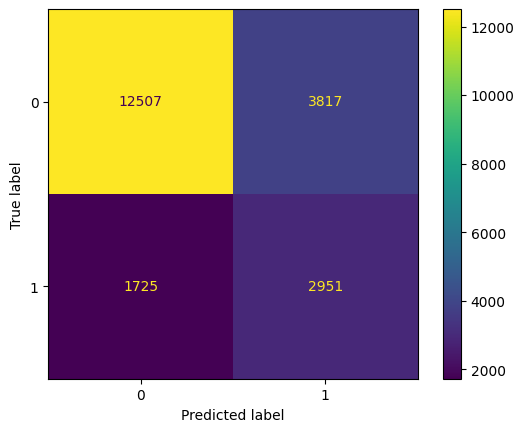

In [25]:
# Show the Scikit learn classification scores
print('Scikit Learn Model')
sckikit_learn_cm = sklearn_metrics(y_train,y_pred, y_pred_proba)

From Scratch model
Loss:0.5829
Accuracy: 0.7360
Precision: 0.4360
Recall: 0.6311
F1-Score: 0.5157
ROC AUC: 0.7547
Confusion Matrix:


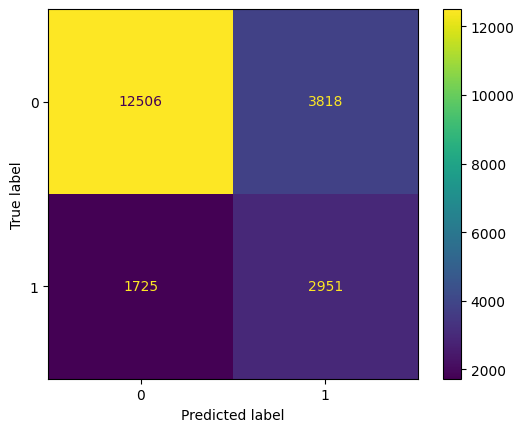

In [26]:
# Show the built from scratch model scores
print('From Scratch model')
scratch_model_cm = sklearn_metrics(y_train, y_pred_scratch, y_pred_proba_scratch)

All scores are the same at least up to the fourth decimal, meaning that the built in model converges as expected with our Benchmark. There is only one difference in the confusion matrix and is only by one missclassified observation for our builtin model. This discrepancies are expected as Scikit-learn models use more sophisticated methods to optimize and minimize the cost function meaning results will not be the same.

An honest approach to determine wether our built in models are working as intended is to meassure the results of each model used and compare them with our benchmark to see how far is the built in model from the benchmark. There are different metrics, coeficients and principal components that are meassurable and comparable with Scikit learn.

A fine method is to use the Euclidean Distance of both meassures and calculate the  absolute error, which is essentially the $L^2$ norm  of a vector.

By definition the norm $L^2$ of a vector $x = [x_1, x_2,...,x_n]$ is denoted as $||x||_2$ and calculated as:

$$ ||x||_2 = \sqrt{x_1^2 + x_2^2+...x_n^2}$$

Then the absolute error of two vectors is the $L^2$ norm of the difference of their absolute values such as:

$$error = || |v_1|-|v_2| ||_2$$

And the relative error is

$$\text{relative error} = \frac{|| |v_1|-|v_2| ||_2}{|| v_1||_2}$$

Where $v_1$ are the benchmark meassures and $v_2$ are the comparing meassures. Let us start with comparing both confussion matrices

In [27]:
# Calculate the relative error of two vectors:
calculate_error = lambda v1,v2: np.linalg.norm(abs(v1) - abs(v2))/np.linalg.norm(v2)

# show results
cm_error = calculate_error(sckikit_learn_cm.flatten(),scratch_model_cm.flatten())
print(f'Relative error between Confusion Matrices: {cm_error*100:.2f}%')

Relative error between Confusion Matrices: 0.01%


Relative error in percentage is 0.01%. Which is very small and also expected as both matrices are almost the same, but it gave us a hint of how does the error formula works. Let us dive in the Logistic Regression coeficients and intercept.

In [28]:
rel_error = calculate_error(log_reg_scratch.w, model.coef_)
intercept_rel_error = calculate_error(log_reg_scratch.b, model.intercept_)

print(f'Relative error between coefficients: {rel_error*100:.2f}%')
print(f'Relative error between intercepts: {intercept_rel_error*100: .2f}%')

Relative error between coefficients: 1.54%
Relative error between intercepts:  0.25%


Both intercept and coefficients are almost equal as the error is less than 1% in the former and around that value on the latter. It is expected that errors in coeficients, representing a vector of size 35, are higher than in an intercept of only one value as every small difference adds up value by value.

It is also expected that if both regression functions are almost equal, the Principal components from which said function is built should also converge. But let us see how starting with the explained variance ratios:

In [29]:
rel_error = calculate_error(pca_scratch.explained_variance, pca.explained_variance_ratio_)
print(f'Relative error between PCA explained variances: {rel_error*100:.3f}%')

Relative error between PCA explained variances: 0.001%


Our method and Scikit learn provide nearly the same result in explained variance or eigenvalues. It must be noted that the method used to extract the Principal Components in this project differs from the common approach.

While we calculated the Covariance Matrix to then calculate the eigenvalues through Jacobian rotations, this former step can be avoided by extracting the Principal Components by Singular Value Decomposition, which is numerically more efficient as it doesnt need a Covariance Matrix to do so.

For simplicity, we went for the Covariance Matrix and Jacobi Method approach. However, SVD provides the same result in less steps and is much more computationally efficient when dimensionality is high.

The final comparison will be component by component vector.

In [30]:
for v in range(len(pca_scratch.components.T)):
    error = calculate_error(pca_scratch.components.T[v], pca.components_[v])
    print(f'Relative error between Principal Components {v+1}: {error*100:.5f}%')

Relative error between Principal Components 1: 0.00987%
Relative error between Principal Components 2: 0.03326%
Relative error between Principal Components 3: 0.09022%
Relative error between Principal Components 4: 0.27749%
Relative error between Principal Components 5: 0.44142%
Relative error between Principal Components 6: 0.56305%
Relative error between Principal Components 7: 0.20831%
Relative error between Principal Components 8: 0.40591%
Relative error between Principal Components 9: 0.87769%
Relative error between Principal Components 10: 0.92188%
Relative error between Principal Components 11: 0.18174%
Relative error between Principal Components 12: 0.47288%
Relative error between Principal Components 13: 1.29251%
Relative error between Principal Components 14: 1.28652%
Relative error between Principal Components 15: 0.45981%
Relative error between Principal Components 16: 0.61363%
Relative error between Principal Components 17: 0.33710%
Relative error between Principal Compone

This is an interesting case. The gap between both methods tend to grow by each component, meaning the highest variance components have a lower error while the components with less variance have a worse convergence.

This happens due to nummerical stability in higher variance components. The higher the variance, the easier it is to perform the rotations and catch the variance for said component. Once the variance is low, performing the givens rotation becomes more and more difficult resulting in unstable results. Therefore, this phenomenom is expected to happen.

We are satisfied with the benchmark comparison as errors are small enough to confirm that our built from scratch models work as intended. It is now time to evaluate and validate before testing.

# Model Evaluation

There are three main ways to evaluate a classification model: By how many correct classifications are (accuracy), by how correct it is each time it predicts the positive class (precision) and by how many mistakes it makes every time it predicts the positive class (recall). These metrics look similar at first glance but understanding the difference between these is crutial in order to develop a model that does the job.

The best model is not often the one that is mostly right, but the one that serves better the business purpose. For instance, the problem of this project is a credit card risk default modelling, where customer might end up paying the credit on full or defaulting it. Each path taken by the client has consequences for the business that issues the credit card. Now, are these consequences equal? Is it the same to give credit to a customer that wont return it in full as it is to not lend any money to one that would? Most surely not. It is most likely that a default is a major blow to a bank than a loss in opportunity cost is. Thus, it is uttermost important for the business to low down default risk as much as possible, even if it means to reject good paying customers, or in other words, to rise up recall metric even if it means to sacrifice precision or accuracy.

If we take another different problem, for instance a doping detection system, where a False Negative (allowing a cheating athlete to compete) might be less damaging than a False Positive (classifying a clean athlete as a cheater, thus destroying a whole career along with its reputation), we might rather pay attention to the precision metric and ensure that if the system classifies an athlete as positive in a dope test it is actually true. Every problem needs a different approach.

Some may ask: why not building a model that can predict both reliably? And that should be the aim of any classification model in an ideal world. However, some problems are just too complex to be solved in such a smooth way. The first approach should be to compare different models or combinations of models that could maximize all metrics without overfitting, but if such thing is not possible it will necessary to choose where to optimize.

The next question might be: How can a model be modified to calibrate these metrics to respond to the business needs? The answer to this question is yes, by hyperparameter tuning. The details of this procedure are on the next section, but by tuning the parameters of the model such as the prediction threshold, it is possible to find the optimum solution of a given model.

Now, how can we evaluate the model and calculate the key metrics to meassure its performance? First we need to fit the model and assign predictions given a threshold which at first will be set arbitrarily at 50% (if a probability of default goes over .50, the model will label the observation as a defaulting client). Once predictions are made, we will need to compare the prediction results with the actual target and count:

- True Negatives (TN): The amount of customers that were labeled as "not defaulting" paid the loan
- True Positives (TP): The amount of customers that defaulted and were labeled as defaulting clients.
- False Negatives (FN): as the amount of clients that were labelled as not defaulting but ended up not paying the loan fully
- False Positives (FP): clients that were labelled as defaulting but paid the loan.

These counts can be the values of a Confusion matrix such as:

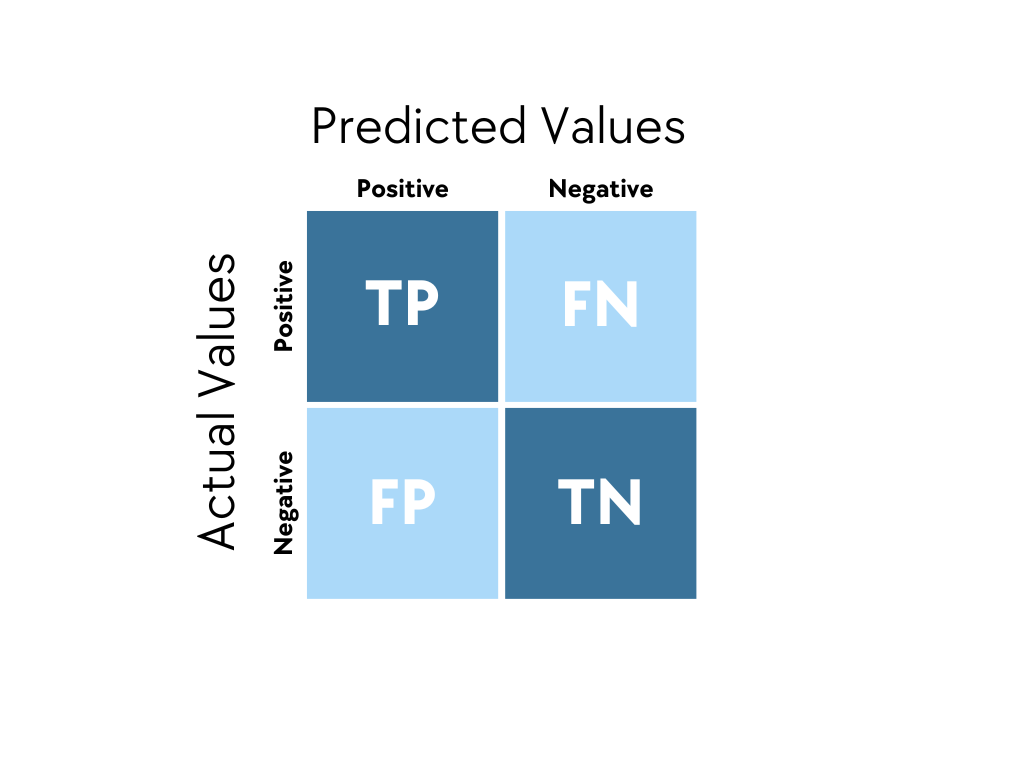


And from these values it is possible to calculate:

$$\text{Accuracy}= \frac{\text{TP} + \text{TN}}{\text{TP}+\text{TN}+\text{FP}+\text{FN}}$$

$$\text{Precision}= \frac{\text{TP}}{\text{TP}+\text{FP}}$$

$$\text{Recall} = \frac{\text{TP}}{\text{TP}+\text{FN}}$$

And also the famous F1 Score as:

$$\text{F1 Score} = 2 \cdot \frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}$$

These are the basic classification scores and give a small hint over how does the model fit the data given a thresfold.

Another common more global metric is ROC AUC Score. The previous metrics meassure the model performance over the predictions of a certain threshold. This ROC AUC score provide a value between 0 and 1 and represents how the model discriminates the positive class over a continious set of thresholds $t \in [0,1]$ and is calculated as follows:

$$\text{ ROC AUC}= ∫^1_0 \text{TPR}(t) \times d(\text{FPR}(t))$$

Where

$\text{TPR}(t) = \frac{\text{TP}(t)}{\text{TP}(t)+\text{FN}(t)}$ and $\text{FPR}(t) = \frac{\text{FP}(t)}{\text{TN}(t)+\text{FP}(t)}$

Since the integral cannot be computed analytically, it is approximated numerically using the trapezoid rule. For a set of thresholds sorted by $FPR$ in ascending order:

$$\text{ ROC AUC} ≈ \sum^{n-1}_{i=1} \frac{\text{FPR}_{i}+\text{FPR}_{i-1}}{2}[\text{TPR}_{i-1}+\text{TPR}_{i}]$$

In an ideal scenario with a balanced dataset ROC AUC score gives a reliable metric of the model performance and its accuracy in general. However, if class balance condition is not met, this score could be unuseful or even misleading just like accuracy score.

A great alternative for this scenario is to use a similar approach but with Precision and Recall scores over all thresholds instead of previous FPR and TPR. Precision-Recall AUC focuses on positive class predictions, thus making this approach more adequate for our problem.

The following class provides all evaluation methods explained above:

In [31]:
class ClassifierEvaluation():

    def __init__(self, y_proba,y_true,model=None):

       self.y_proba = y_proba
       self.y_true = np.asarray(y_true)
       self.model = model

       self.confusion_matrix = None

       self.metrics = {}
       self.accuracy = None
       self.precision = None
       self.recall = None
       self.f1_score = None

       self.brier_score = np.mean((self.y_true - self.y_proba)**2)
       self.train_loss = model.logloss if model is not None else None
       self.test_loss = model.loss(self.y_proba,self.y_true) if model is not None else None


       self.thres = None
       self.tpr = None
       self.fpr = None
       self.precision_list = None
       self.recall_list = None
       self.f1_score_list = None
       self.roc_auc_score = None
       self.pr_auc_score = None

       self.best_threshold = None
       self.min_cost = None

    def class_counts(self, threshold=0.5):

        y_pred = (self.y_proba >= threshold).astype(int)

        TP = np.sum((y_pred == 1) & (self.y_true == 1))
        TN = np.sum((y_pred == 0) & (self.y_true == 0))
        FP = np.sum((y_pred == 1) & (self.y_true == 0))
        FN = np.sum((y_pred == 0) & (self.y_true == 1))

        return y_pred, TP, TN, FP, FN

    def classification_scores(self, threshold = 0.5):


        y_pred, TP, TN, FP, FN = self.class_counts(threshold)

        self.confusion_matrix = np.array([[TP, FN], [FP, TN]])

        self.accuracy = np.sum(y_pred == self.y_true) / np.size(self.y_true)
        self.precision = TP / (TP + FP) if (TP + FP) != 0 else 0.0
        self.recall = TP / (TP + FN) if (TP + FN) != 0 else 0.0
        self.f1_score = 2 * (self.precision * self.recall) / (self.precision + self.recall)

    def trapezoid_integral(self, x, y):

        dx = np.diff(x)
        h = (y[:-1]+ y[1:])/ 2

        area = np.sum(h*dx)
        return area

    def evaluate_scores(self):

        tpr_list = []
        fpr_list = []
        precision_list = []
        recall_list = []
        f1_score_list = []

        unique_probas = np.sort(np.unique(self.y_proba))[::-1]

        self.thres = np.concatenate([[1.0], unique_probas,[0.0]])

        for i in self.thres:
          _, TP, TN, FP, FN = self.class_counts(i)


          TPR = TP/(TP+FN) if (TP+FN) != 0 else 0
          FPR = FP/(FP+TN) if (TN+FP) != 0 else 0
          tpr_list.append(TPR)
          fpr_list.append(FPR)

          precision = TP/(TP+FP) if (TP+FP) != 0 else 1
          recall = TP/(TP+FN) if (TP+FN) != 0 else 0
          f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

          precision_list.append(precision)
          recall_list.append(recall)
          f1_score_list.append(f1_score)

        roc_indices = np.argsort(fpr_list)
        pr_indices = np.argsort(recall_list)

        self.tpr = np.array(tpr_list)[roc_indices]
        self.fpr = np.array(fpr_list)[roc_indices]
        self.precision_list = np.array(precision_list)[pr_indices]
        self.recall_list = np.array(recall_list)[pr_indices]
        self.f1_score_list = np.array(f1_score_list)[pr_indices]

        self.roc_auc_score = self.trapezoid_integral(self.fpr, self.tpr)
        self.pr_auc_score = self.trapezoid_integral(self.recall_list,self.precision_list)

    def calculate_threshold(self, FP_cost,FN_cost):

        cost_matrix = np.array([[0,FN_cost],[FP_cost,0]])

        best_threshold = None
        min_cost = float("inf")

        for t in self.thres:
          _, TP, TN, FP, FN = self.class_counts(t)
          cm = np.array([[TP,FN],[FP,TN]])
          total_cost = np.sum(cm * cost_matrix)

          if total_cost < min_cost:
              min_cost = total_cost
              best_threshold = t

        self.best_threshold = best_threshold
        self.min_cost = min_cost


    def show_metrics(self):
        disp = ConfusionMatrixDisplay(confusion_matrix=self.confusion_matrix, display_labels=['Default','Pay'])
        if self.test_loss != None:
            print(f'Loss: {self.test_loss:.4f}')
        print(f'Accuracy:{self.accuracy:.4f}')
        print(f'Precision: {self.precision:.4f}')
        print(f'Recall: {self.recall:.4f}')
        print(f'F1-Score: {self.f1_score:.4f}')
        print(f'\nConfusion Matrix:')
        disp.plot()

    def plot_curve(self, x, y, x_label=None, y_label=None, title=None, AUC=None, ax=None):
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(7, 5))

        sns.lineplot(x=x, y=y, ax=ax)                        # ✅ ax=ax
        ax.set_xlabel(x_label)                                # ✅ set_xlabel
        ax.set_ylabel(y_label)
        ax.set_title(title)
        ax.set_xlim(0, 1)
        ax.text(0.1, 0.9, f"AUC: {AUC:.4f}")
        ax.grid(True)

        if standalone:
            plt.tight_layout()
            plt.show()


    def plot_PR_tradeoff(self, decision=0, FN_cost=2500, FP_cost=500, ax=None):
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(7, 5))

        cost_matrix = np.array([[0, FN_cost], [FP_cost, 0]])
        _, TP, TN, FP, FN = self.class_counts(decision)
        cm = np.array([[TP, FN], [FP, TN]])
        total_cost = np.sum(cm * cost_matrix)

        sns.lineplot(x=self.thres, y=self.precision_list, label='Precision', ax=ax)   # ✅
        sns.lineplot(x=self.thres, y=self.recall_list, label='Recall', ax=ax)
        sns.lineplot(x=self.thres, y=self.f1_score_list, label='F1 Score', ax=ax)
        ax.axvline(x=decision, color='red', linestyle='--')
        ax.set_xlabel('Threshold')                            # ✅ set_xlabel
        ax.set_ylabel('Scores')
        ax.set_title('Precision-Recall Trade-off')
        ax.set_xlim(0, 1)                                     # ✅ set_xlim
        ax.text(decision + 0.05, 0.75, f'Total cost:{total_cost}')
        ax.grid(True)

        if standalone:
            plt.tight_layout()
            plt.show()


    def plot_loss_function(self, y_train, ax=None):
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(7, 5))

        p = y_train.mean()
        baseline = -(p * np.log(p) + (1 - p) * np.log(1 - p))

        sns.lineplot(x=range(len(self.train_loss)), y=self.train_loss,
                     label='Model Loss', ax=ax)               # ✅
        ax.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline: {baseline:.4f}')
        ax.set_xlabel('Iterations')                           # ✅
        ax.set_ylabel('Log Loss')
        ax.set_title('Log Loss Function')
        ax.legend()
        ax.text(round(len(self.train_loss) * 0.65), 0.65, f"Test Loss: {self.test_loss:.4f}")
        ax.text(round(len(self.train_loss) * 0.65), 0.64, f"Test Brier Score: {self.brier_score:.4f}")
        ax.grid(True)

        if standalone:
            plt.tight_layout()
            plt.show()


    def reliability_diagram(self, n_bins=10, title='Reliability Diagram', ax=None):
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(7, 5))

        p = self.y_true.mean()
        prevalence = p * (1 - p)
        bin_edges = np.linspace(0, 1, n_bins + 1)
        bin_means, bin_fracs = [], []

        for i in range(n_bins):
            mask = (self.y_proba >= bin_edges[i]) & (self.y_proba < bin_edges[i + 1])
            if mask.sum() > 0:
                bin_means.append(self.y_proba[mask].mean())
                bin_fracs.append(self.y_true[mask].mean())

        ax.plot(bin_means, bin_fracs, 'o-', label='Model')
        ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Real Positives proportion')
        ax.set_title(title)
        ax.text(0.05, 0.90, f'Brier Score: {self.brier_score:.4f}')
        ax.text(0.05, 0.82, f'Base line: {prevalence:.4f}')
        ax.legend()
        ax.grid(True)

        if standalone:
            plt.tight_layout()
            plt.show()


    def plot_scores(self, decision=0.0, n_bins=10):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        self.reliability_diagram(n_bins=n_bins, ax=axes[0, 0])
        self.plot_curve(self.fpr, self.tpr, 'FPR', 'TPR', 'ROC Curve',
                        self.roc_auc_score, ax=axes[0, 1])
        self.plot_curve(self.recall_list, self.precision_list, 'Recall', 'Precision',
                        'Precision-Recall Curve', self.pr_auc_score, ax=axes[1, 0])
        self.plot_PR_tradeoff(decision=decision, ax=axes[1, 1])

        plt.tight_layout()
        plt.show()


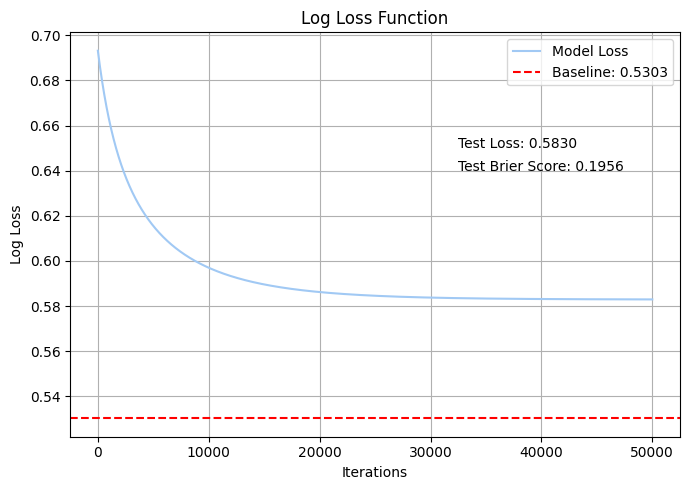

In [32]:
scores = ClassifierEvaluation(y_pred_proba_scratch,y_train,log_reg_scratch)
scores.plot_loss_function(y_train=y_train)


First plot is the Cost Function. Every iteration of the optimization process, the cost function is updated with each new value of the weights $w$. As Cost function represents how far are predictions from the real values it is best that the output is as small as possible, where value of 0 means the predictions are perfect with no errors.

To understand if this metric is good, it has to be compared with the prevalence value. For instance, for a balanced dataset, a "dumb" or random model should give every prediction the probability $p=0.5$ and for our credit card default data the probability $p(y=1)≈0.22$ meaning that a "dumb" classifier would just assign the value of $0.2$ to every prediction in our case. Finally, our baseline $b(p)$ is calculated similarly as the cross entropy function:

$$b(p)= -[p \cdot log(p) + (1-p) \cdot log(1-p)]$$

where $p$ is the prior probability of being in the positive class. From baseline it is possible to ascertain how far are predictions or probabilities of default given $w$ and how does our model discriminate and learn from the data. If model loss is over the baseline, it means that performance is not better than randomly assigning classes and is a clear sign of underfitting. Otherwise, if the model cost function drops below the baseline, it means it is capable of learning from the data. If there is a great discrepancy between training and test cost function values it is probably overfitting.

Brier score meassures model fit similarly to Cross Entropy function.

$$\text{Brier Score} = \frac{1}{N}\sum^N_{i=1}(y_i-\hat{y}_i)^2$$

The main difference with the Cross Entropy function is that Brier Score does not penalize harshly when the model is confidently wrong (like predicting a positive class with 0.9 when the true label is 0) due to the effect of squaring the error. This score is the regression equivalent of MSE.

Again, there is a baseline to this score given an imbalanced dataset and is calculated as follow:

$$\text{prevalence} = p(1-p)$$

Where $p$ is the prior probability. This formula is the same as the Variance of a Bernoulli Distribution.

This plot showcase that baseline is at 0.53 while model loss is always over 0.58, meaning the model is clearly underfitting. Although it is suboptimal, it is not encouraged to discard a model based on that alone. Having a useful but easy model is often more valuable than having a black box with perfect fit. That being said, it is expected that a model trained with balanced class weights to be less accurate than the vanilla model in terms of probabilities as we are introducing a bias to the model for the sake of maximizing recall and identify better the positive class this bias tend to inflate the positive class probabilities.

Like said before, a model does not have to make the most accurate predictions in order to work, it has to provide business value and help with decision making.

Next plots will showcase other metrics that are also relevant for the model and most importantly, to the business.

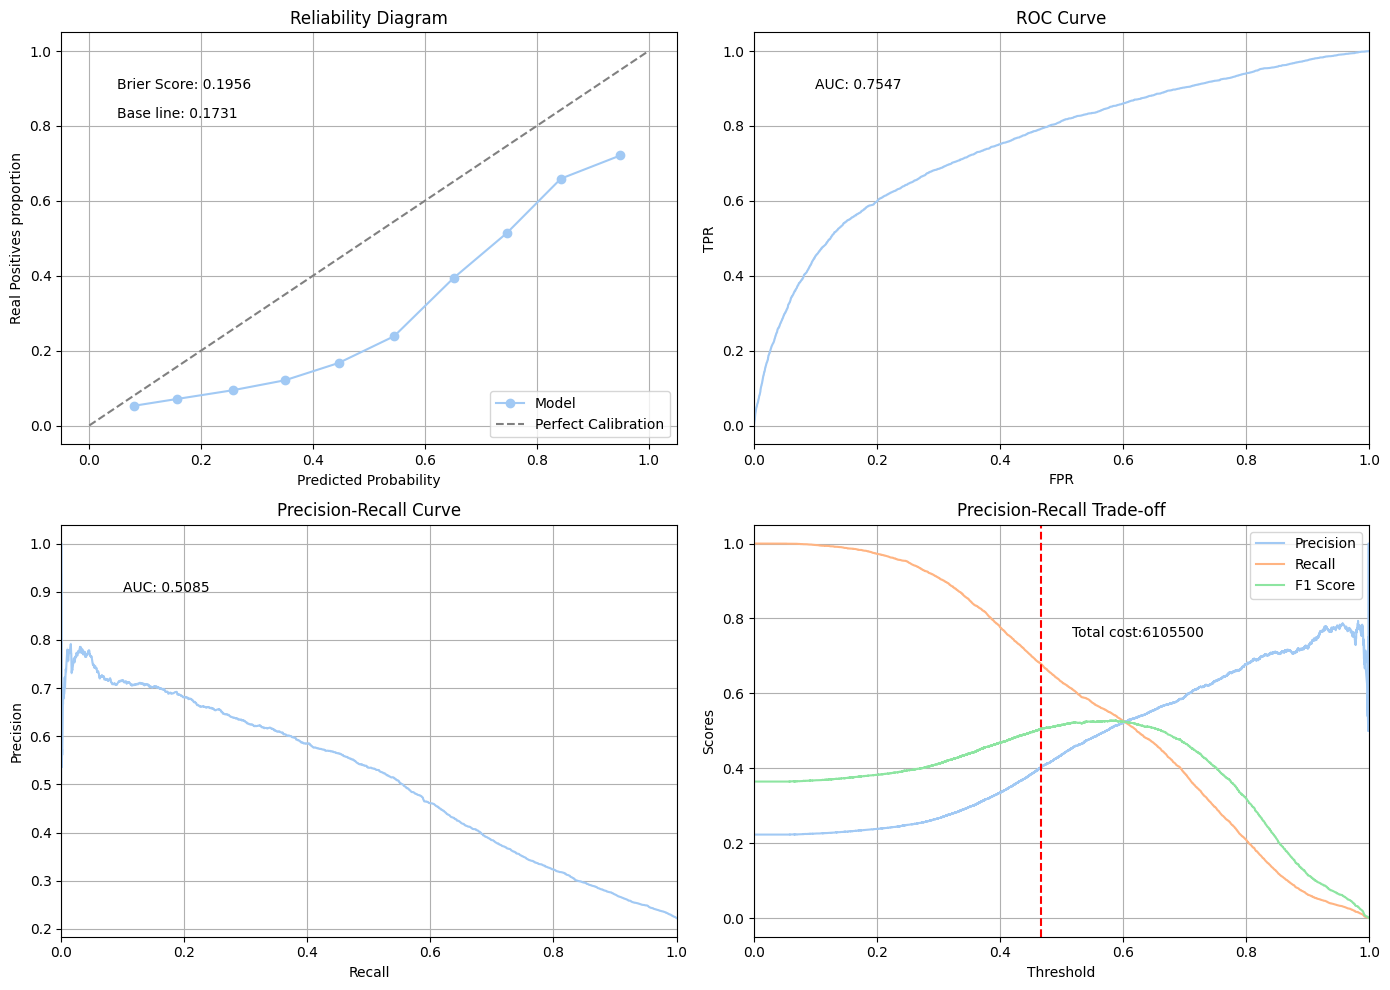

In [33]:
scores.classification_scores()
scores.evaluate_scores()
scores.calculate_threshold(500,2500)

scores.plot_scores(decision=scores.best_threshold)

### Reliability Diagram
The first plot in this section is a Reliability Diagram. When evaluating a classification model it is important to know if it is well calibrated. Every prediction made is a probability from 0 to 1, in that case, if a well calibrated model predicts the positive class with an 80% chance, then it should be right around an 80% of the time. This plot compares the model prediction probabilities with that of a perfect calibrated model. An overconfident model (below the line of perfect predictions) tends to predict an outcome with higher probabilities than the real statistical accuracy and underconfident model assigns lower probabilities than said accuracy. Here it is visually likely that our model is over confident as predictions of probabilities are usually higher.

An overconfident model could present a problem for the business if it is used to make individual decisions for each observation. In our case it could mean that the model could not be properly scoring the clients. It also presents an issue if an expected loss is needed to be calculated and Probability of Default is not presented accurately or it could even bring legal or regulatory issues if the model is not transparent enough. Fortunately, there are different methods to correct this problem. The approach taken in this project is by adjusting a second logistic model where input shall be the probabilities from the actual model, and the output are the new calibrated probabilities. This approach is called Plat Scaling.

### ROC  and PR Curve
ROC AUC Score is 0.75, which is not great given that we are testing on the training set. But at least there is no sign of overfitting. However, the more important metric is PR AUC and its score is ~0.51. At first glance it might look is not great, but the benchmark of this score is the prior probability of default, or in other words, the proportion of defaults in the sample which is around 0.22.

This last score means that our model can detect the positive class a 127% better than randomness. Wether if it is good enough or not should be decided by the business and also by comparison with other models, both out of the scope of this project. Although it is an improvement.

ROC and PR plot also gives important information about the model itself. Every data point for this graph represents an actual score of predictions on the y-axis given a threshold that equals the metrics in x-axis. Take ROC curve for instance, this plot shows the True Positive Rate for each threshold where the goal should be to select a threshold to maximize this metric and at the same time minimizing the FPR. Although it is not quite clear where to place this threshold, it is clear that from a $t=0.15$ the upper trend starts to diminish and gains of TPR starts to diminish the higher the threshold.

### Precision-Recall Trade-off

For PR curve it is a bit more complex to choose as it is a downward trend line which is quite simple to explain: the higher the threshold, the lower the precision and vice versa, meaning there is no free lunch with this model: either precission or recall must be sacrificed to maximize the other.

Last plot showcase both of these metrics in y-axis and the thresholds in x-axis. We can see how the precision rises the higher the threshold and on the contrary recall drops lower. The red dotted vertical line is the chosen threshold which is the best for this problem.

How is that threshold calculated? Next section the method *calculate_threshold* where this question will be answered



# Cost Matrix and Decision Making

In the previous evaluation section most relevant classification metrics were explained. The distinction between precision and recall is crutial for the business and for model usefulness as sometimes is not possible to maximize both at the same time. However, after choosing which meassure pioritize how can we set the threshold to achieve the better balance?

It could be set arbitrarily to a point that maximizes our metric (recall in our case) and we are comfortable with. There wont be any business at all if bank do not lend any money. But by setting arbitrarily a threshold we might not get an optimum solution for the problem.

An extended approach to this problem is by comunicating with the business side of the problem. In real-world credit risk modeling, the classification threshold should be determined by the **business costs** associated with each type of error, not purely by statistical metrics.

Each error has associated costs that can determine the decision of the business and model should reflect that accordingly. So for a credit risk modelling the consequences of each error are the following:


**False Positive (FP):** Predicting default when the client would have paid.
- **Business impact:** Rejecting a good customer
- **Cost components:**
  - Lost interest income over the customer lifetime
  - Lost fees and commissions
  - Opportunity cost of the credit line


**False Negative (FN):** Predicting no default when the client actually defaults.
- **Business impact:** Granting credit to a client who will not repay
- **Cost components:**
  - Outstanding balance at default
  - Accrued unpaid interest
  - Collection and legal costs
  - Recovery rate
  - Regulatory capital requirements (Basel III)
  - Reputational damage and increased funding costs

The ratio between FN and FP costs can vary depending on:
- Average outstanding balance of defaulters
- Recovery rates in the jurisdiction
- Customer lifetime value
- Regulatory environment
- Bank's risk appetite

For this analysis, we use **arbitrary costs** of FP = 500 and FN = 2500 (ratio 1:5) as an illustrative example. In practice, **these values should be determined by the business stakeholders** based on:
- Historical default data
- Recovery department performance
- Strategic business objectives
- Competitive positioning

The optimal threshold $t$ is then found by minimizing the total expected cost across all predictions as follows:

$$\text{Total Cost}= Cost_{FP} \cdot FP(t) + Cost_{FN}\cdot FN(t)$$


Loss: 0.5830
Accuracy:0.7058
Precision: 0.4041
Recall: 0.6775
F1-Score: 0.5063

Confusion Matrix:


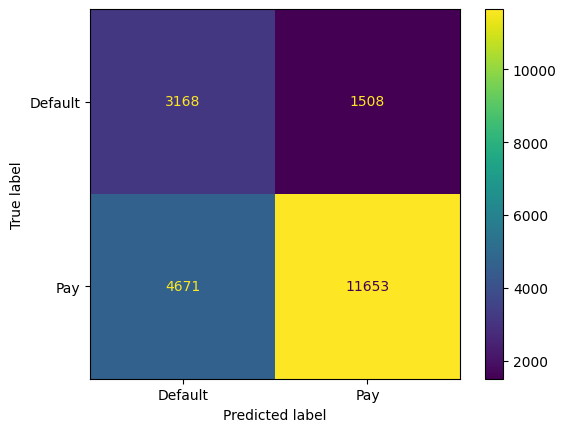

In [34]:
scores.classification_scores(threshold=scores.best_threshold)
scores.show_metrics()

# Model Pipeline

Once the evaluation metrics are explained and selected and the criteria for the threshold implemented it is the moment of starting tha actual training of the model. Up until now we have opened two black boxes in Machine Learning: Principal Component Analysis and Logistic Regression with L2 Regularization. There goes nothing. It was also implemented and tested evaluation methods to check the fit of the model and how it is capable of detecting possible defaults.

Next step is the most computationally intense but also necessary to build a robust model and ascertain that the fit is correct. Let us start with the validation process.

## Cross Validation & Hyperparameter Tuning

Cross validation and Hyperparameter tuning are two different process that are normally done in the same workflow. While the former has the porpose of testing or better to say, validate the model in the training set before the actual test (just like a mock test before an exam); the latter is all about selecting which parameters of the model are best to fit the data (such as number of components in PCA, learning rate for the logistic regression optimizer or even if its better to not do a PCA at all).

Starting with cross validation, the way it works is by taking the training set, and randomly split it again in $k$ folds. One of these folds is reserved as a validation set and the others are for model fitting. Once training is done, the predictions are made and compared with the validation set. This process is repeated $k$ times until all folds are used for validation. This allows to get different evaluations from the training set before the real test and to see how robust it is. If the model scores varies too much from fold to fold it might be a signal of high variance or overfitting, or on the contrary, if results are consistently poor, it might be a bias problem or underfitting.

Given that our data is highly imbalanced, folds should not remain purely random as it might trigger instability in the process and high variance. Instead, for this problem, we will stratify the folds so the distribution of the target are represented across all $k$ folds. Following code performs this algorithm to the training set.

In [35]:
from sklearn.model_selection import StratifiedKFold



def stratified_cv(X,y, n_components, learning_rate, n_iter, lambda_param,fit_pca=True,class_weight=True,early_stopping= 300):

    skf = StratifiedKFold(shuffle= True, random_state = 42)

    folds = []


    for train_idx, val_idx in skf.split(X, y):

        X_fold_train = X.iloc[train_idx].copy()
        X_fold_val = X.iloc[val_idx].copy()
        y_fold_train = y.iloc[train_idx].to_numpy()
        y_fold_val = y.iloc[val_idx].to_numpy()

        start = perf_counter()

        _,model,y_val_pred, y_val_proba = scratch_model_pipeline(X_train=X_fold_train,
                                                             X_test= X_fold_val,
                                                             y_train=y_fold_train,
                                                             n_components=n_components,
                                                             learning_rate=learning_rate,
                                                             n_iter=n_iter,
                                                             lambda_param=lambda_param,
                                                             fit_pca=fit_pca,
                                                             class_weight=class_weight)
        end = perf_counter()
        training_time = end - start

        scores = ClassifierEvaluation(y_val_proba,y_fold_val,model)
        scores.evaluate_scores()
        scores.classification_scores()



        folds.append({
              'Log_Loss': scores.test_loss,
              'Brier_score':scores.brier_score,
              'Precision': scores.precision,
              'Recall': scores.recall,
              'F1_Score': scores.f1_score,
              'PR_AUC':scores.pr_auc_score,
              'Training_Time':training_time,
              'Actual_Iterations':model.n_iter_real
          })

    return folds

Once the Stratified validation process is implemented, next step is to perform a Hyperparameter tuning. This process is performs multiple trainings using diferent parameters each iteration. Here it will be checked if there is an improvement in using PCA or not and how many components are best. how many iterations should the logistic regression optimize to calculate the weights, or how strong should the regularization be.

There are many ways to search the optimum parameters of the model. A basic approach is to manually try a small set of combinations arbitrarily. It is a straight forward approach and might be quite simple, but if the analyst has a deep knowledge of the model and the problem, it is not bad approach and would allow to end quickly a job that otherwise could be tedious. The automatic version of this approach is a Grid Search. Here the different combinatios are set by the analyists and the code will train and compare each evaluation.

Another approach that works best if there is no clear idea as to which combination works best is to try them randomly using a Random Search. This way there will be a set of parameter combinations that will randomly feed the model for a selected amount of iterations or time limit. This is more efficient than grid_search as it allows the exploration of a wide range of parameters with much less iterations.

Other common aproach is Bayesian optimization. This search evaluates previous scores from past trainings and adjust accordingly to maximize the score of the next training until reaching the number of iterations or a time limit.

For simplicity, computational cost and because we want to explore a wide range of parameters, the approach of this project for hyperparameter tunning will be by random search and the code to perform the training is as follows:

In [36]:
from joblib import Parallel, delayed

def evaluate_grid(X,y,params):

  folds = stratified_cv(X,y, n_components=params['PCA_Components'],
                        learning_rate=params['Learning Rate'],
                        n_iter=params['Iterations'],
                        lambda_param=params['Lambda'],
                          fit_pca=params['Fit_PCA'],
                        class_weight=params['Class Weights'])

  folds_df = pd.DataFrame(folds)

  return {**params,
            'Log_loss_mean': folds_df['Log_Loss'].mean(),
            'Log_loss_std': folds_df['Log_Loss'].std(),
            'Brier_Score_mean': folds_df['Brier_score'].mean(),
            'Brier_Score_std': folds_df['Brier_score'].std(),
            'Precision_mean': folds_df['Precision'].mean(),
            'Recall_mean': folds_df['Recall'].mean(),
            'F1_mean': folds_df['F1_Score'].mean(),
            'F1_std': folds_df['F1_Score'].std(),
            'PR_AUC_mean':folds_df['PR_AUC'].mean(),
            'PR_AUC_std':folds_df['PR_AUC'].std(),
            'avg_Training_Time': folds_df['Training_Time'].mean(),
          'avg_actual_iterations':folds_df['Actual_Iterations'].mean()
        }

def random_search(X,y,param_distr,n_iter=30,n_jobs=-1):

    np.random.seed(42)
    keys = list(param_distr.keys())

    param_list = [{key:np.random.choice(param_distr[key]) for key in keys} for _ in range(n_iter)]

    results = Parallel(n_jobs=n_jobs, verbose=10, backend='loky')(delayed(evaluate_grid)(X, y, params) for params in param_list)

    results_df = pd.DataFrame(results)
    results_df['PCA_Components'] = np.where(results_df['Fit_PCA']== False, None, results_df['PCA_Components'])
    return results_df.sort_values('PR_AUC_mean', ascending=False).reset_index(drop=True)



In [37]:
param_grid = {'PCA_Components': [10, 20,35],
              'Learning Rate': [0.01, 0.001],
              'Iterations': [10000,20000],
              'Lambda':[0.1,1, 10,50, 100],
              'Fit_PCA':[True, False],
              'Class Weights':[True,False]}

result_df = random_search(X_train, y_train,param_grid)
result_df

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   55.1s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  8.7min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed: 18.6min
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed: 23.2min
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed: 30.7min finished


,PCA_Components,Learning Rate,Iterations,Lambda,Fit_PCA,Class Weights,Log_loss_mean,Log_loss_std,Brier_Score_mean,Brier_Score_std,Precision_mean,Recall_mean,F1_mean,F1_std,PR_AUC_mean,PR_AUC_std,avg_Training_Time,avg_actual_iterations
0,20,0.010,20000,50.0,True,False,0.460400,0.005530,0.143066,0.001951,0.671775,0.249356,0.363694,0.014831,0.511143,0.016719,8.297091,3322.0
1,None,0.010,10000,1.0,False,False,0.454190,0.005581,0.142735,0.001989,0.665675,0.257695,0.371465,0.016528,0.511023,0.016533,9.038901,3604.8
2,None,0.010,20000,0.1,False,False,0.454139,0.005572,0.142736,0.001992,0.665675,0.257695,0.371465,0.016528,0.511003,0.016552,8.875304,3556.0
3,None,0.010,20000,0.1,False,False,0.454139,0.005572,0.142736,0.001992,0.665675,0.257695,0.371465,0.016528,0.511003,0.016552,8.708660,3556.0
4,20,0.010,20000,100.0,True,False,0.465481,0.005446,0.143216,0.001933,0.673808,0.243368,0.357566,0.015466,0.510993,0.016685,7.936766,3193.2
5,20,0.001,20000,50.0,True,False,0.460946,0.004636,0.143800,0.001771,0.675895,0.237379,0.351322,0.015363,0.510427,0.016606,43.613888,18643.8
6,20,0.001,20000,100.0,True,False,0.465371,0.004646,0.143958,0.001743,0.679777,0.231177,0.344994,0.014799,0.510396,0.016650,44.560051,18400.8
7,None,0.001,20000,1.0,False,False,0.455570,0.004961,0.143348,0.001888,0.665024,0.264114,0.377967,0.009687,0.509464,0.016766,43.523122,17470.0
8,None,0.001,20000,1.0,False,False,0.455570,0.004961,0.143348,0.001888,0.665024,0.264114,0.377967,0.009687,0.509464,0.016766,42.130529,17470.0
9,35,0.001,10000,0.1,True,False,0.464383,0.003271,0.146522,0.001382,0.679337,0.220056,0.332413,0.016392,0.509370,0.015768,29.497802,10000.0


Seems that models trained with PCA get similar scores to those trained with the original dataset in PR AUC score and also in training time. This differences are likely to be only by chance as the differences are very subtle.

As a learning rate of 0.01 converges to the optimum solution just as fine as 0.001, we know that the former is a more eficient parameter for this model in terms of computational cost. Therefore, future trainings will be done with said learning rate.

Class weights tend to bias the model and gets lower performance affecting the acuracy and precission and maximizing recall. As this latter metric is one of our biggest priorities to minimizing costs, next validation model shall include this feature along with a post-hoc calibration to increase model robustness including certain probabilities. The goal is minimize Brier Score and Cross Entropy function while keeping the other metrics equal.

PCA models tend to work better with regularization, while the original dataset have different metrics without it. As there is no much difference in any metric, The selected model should be the simplest one. First step will be to choose the best two models of each dataset (one from the projected dataset and one from the original one with strong regularization). From each model we will select the features or variables that are most important for modelling and finally, we will put our model to our final test.

It is important to note that due to computational cost, only a sample of 30 models was taken when the range of all parameters is 7 and much more combinations should be tested in a real scenario.

## Platt Scaling Calibration



As mentioned before, it is important for a probability based model that its prediction is aligned with the real likelihood of the events. A model that represents said likelihood accurately is a calibrated model. It is also important for a business that makes critical decisions based on the predicted probabilities that this probabilities are calibrated to be sure that the decisions are aligned with the problem.

In this case, for a credit risk model, it might not be critical if thresholds or decisions are made by using a cost matrix or model selection is made purely by AUC scores as the threshold is based purely on the probability rankings from the model output. But if there are further calculations required from the financial entity, this probability of default must be accurate. For instance, an important KPI widely used in the loan industry is the Expected Loss (EL) which is calculated as follows:

$$EL = PD \times LGD \times EAD$$

Where $PD$ is the probability of default, $LGD$ is the Loss Given Default metric and represents a proportion of capital at risk of permanent loss from the Exposure at Default metric or $EAD$ which is the predicted amount of capital loss the lender might face given a default.

Each one of this metrics are challenging to calculate, but are critical to a business where every decision matters and many decisions are made based on that value. A bank might use the Probability of default to asign a credit score to a client, for instance or adjust the capital reserve in compliance with Basel III regulatory framework using the expected loss output. If Probability of default does not reflect true likelihood accordingly, this KPIs will likely be wrong and so will decisions made by using this KPI.

So now that we know the "why" the next answer needed is the "how". There are several calibration methods that can adjust the model output accordingly. A fine option is to adjust regularization to higher levels to reduce noise. However, as some bias was introduced with class weights, this option might not work as intended and can even make a useless model if regularization is too strong by colapsing all range of probabilities in fewer values. Thus trying to calibrate the model while introducing bias at the same time will not provide succesful results.

Another alternative is to calibrate the model after the training during the validation phase. An instance of this is Plat Scaling method. This method assumes a sigmoidal relationship between the model output and the posterior probabilities. Meaning:

$$P(y=1|x) = \frac{1}{1+e^{ax+b}}$$

Where $a$ is the adjusting factor to the prior probabilities $x$ given the earliest output and $b$ is the intercept or bias. If this formula seems familiar is not pure coincidence. It is the same sigmoid function used in the Logistic regression, and the way to find the posterior probabilities is by Maximum Likelihood Estimation by differentiating the Cost Function, exactly the same as before when the model was adjusted. So it basically means to fit another model only for the probabilities output, without introducing bias or regulation.

Following Class has the goal of performing the calibration on a validation set. It is important not train the calibration on the validation or test set as it would incur a Data Leakage.

In [38]:
class ModelCalibration():

    def __init__(self,X,y):
        self.X = X
        self.y = np.asarray(y).flatten()
        self.y_proba_oof = None
        self.model = None
        self.platt_model = None

    def platt_scaling(self, y_proba, y_true, y_proba_apply):

        X_calib = y_proba.reshape(-1, 1)
        X_apply = y_proba_apply.reshape(-1, 1)

        platt_model = LogisticRegression_scratch(
            learning_rate=0.1,
            n_iter=10000,
            lambda_param=0.0,
            class_weight=False)

        platt_model.fit(X_calib, y_true)

        y_proba_calibrated = platt_model.predict_proba(X_apply)
        self.platt_model= platt_model

        return y_proba_calibrated

    def get_oof_probabilities(self, n_components=35, learning_rate=0.01, n_iter=20000, lambda_param=0, thres = 0.5,class_weight=False,fit_pca=False,component_list=None):

            skf = StratifiedKFold(shuffle= True, random_state = 42)

            oof_proba = np.zeros(len(self.y))

            for train_idx, val_idx in skf.split(self.X, self.y):

                X_fold_train = self.X.iloc[train_idx].copy()
                X_fold_val = self.X.iloc[val_idx].copy()
                y_fold_train = self.y[train_idx]

                _,model,_, y_val_proba = scratch_model_pipeline(X_train=X_fold_train,
                                                                     X_test= X_fold_val,
                                                                     y_train=y_fold_train,
                                                                     n_components=n_components,
                                                                     learning_rate=learning_rate,
                                                                     n_iter=n_iter,
                                                                     lambda_param=lambda_param,
                                                                     thres=thres,
                                                                     class_weight = class_weight,
                                                                     fit_pca=fit_pca,
                                                                     component_list=component_list)

                oof_proba[val_idx] = y_val_proba
            self.y_proba_oof = oof_proba
            self.model = model

    def calibrate(self):
        y_calibrated = self.platt_scaling(y_proba=self.y_proba_oof,
                                          y_true= self.y,
                                          y_proba_apply=self.y_proba_oof)
        return y_calibrated

In [39]:
def calibration_metrics(X_train,y_train, show_plots=False, calibrate_model = True, n_components=20, learning_rate=0.01, n_iter=20000, lambda_param=1, thres = 0.5,class_weight=True,fit_pca=True, component_list= None):

    calibration = ModelCalibration(X_train,y_train)
    calibration.get_oof_probabilities(n_components=n_components, learning_rate=learning_rate, n_iter=n_iter, lambda_param=lambda_param,class_weight=class_weight, thres = thres,fit_pca=fit_pca, component_list= component_list)

    if calibrate_model:
        oof_pred = calibration.calibrate()
        validation = ClassifierEvaluation(oof_pred,y_train, calibration.platt_model)
    else:
        oof_pred = calibration.y_proba_oof
        validation = ClassifierEvaluation(oof_pred,y_train, calibration.model)


    validation.evaluate_scores()
    validation.calculate_threshold(500,2500)
    validation.classification_scores(validation.best_threshold)

    if show_plots:
        validation.plot_scores(decision = validation.best_threshold)
        validation.show_metrics()

    return validation

First we are going to train the model with the projected Dataset and evaluate the preformance again adding plots and using the cost matrix

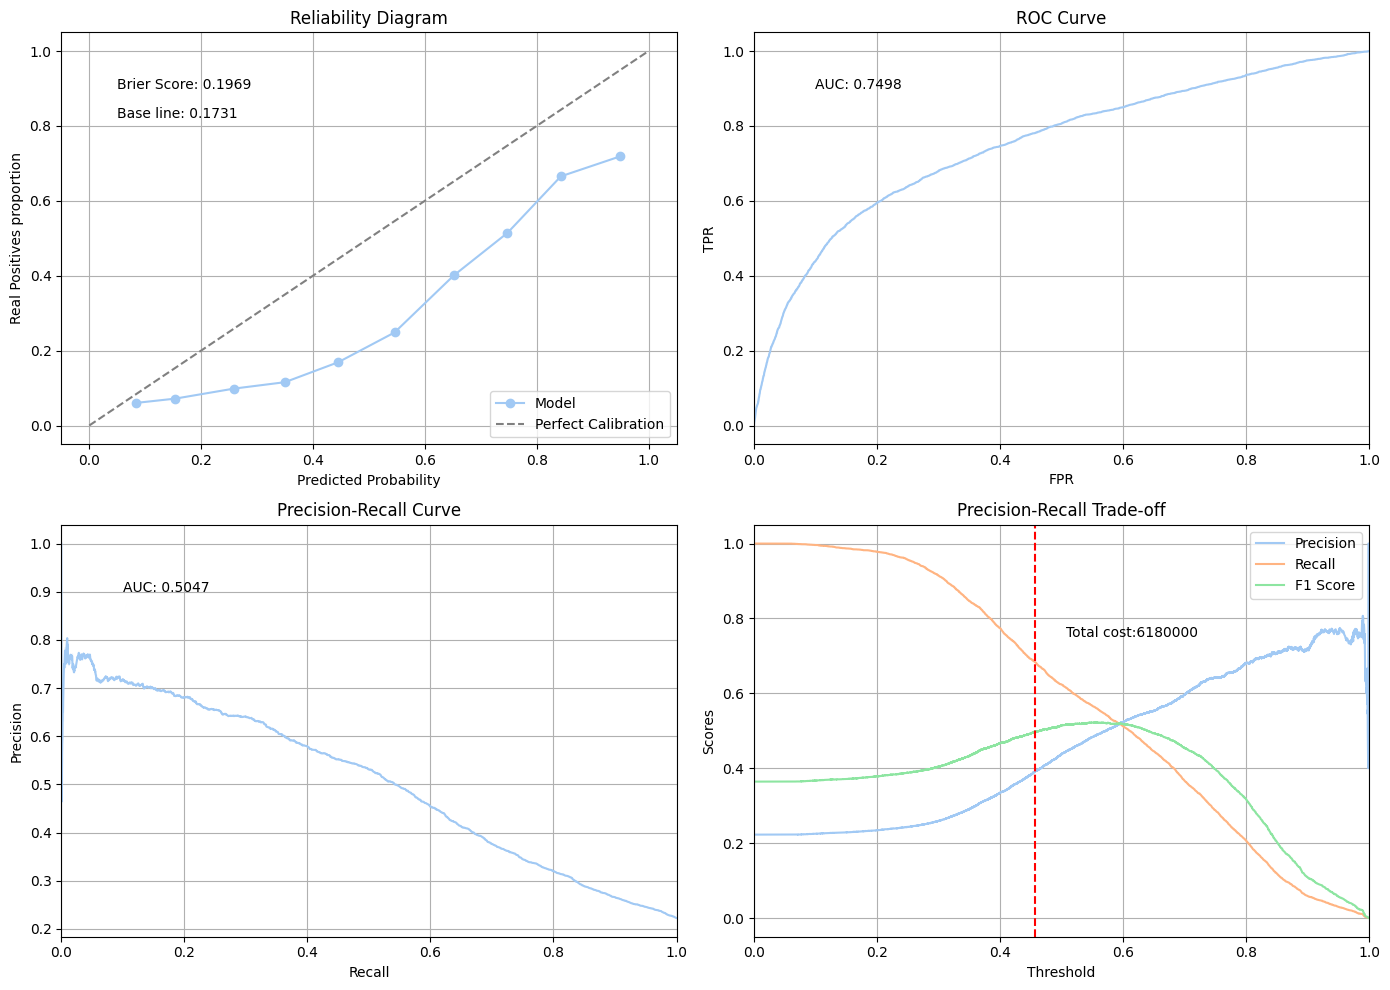

Loss: 0.5875
Accuracy:0.6933
Precision: 0.3919
Recall: 0.6835
F1-Score: 0.4981

Confusion Matrix:


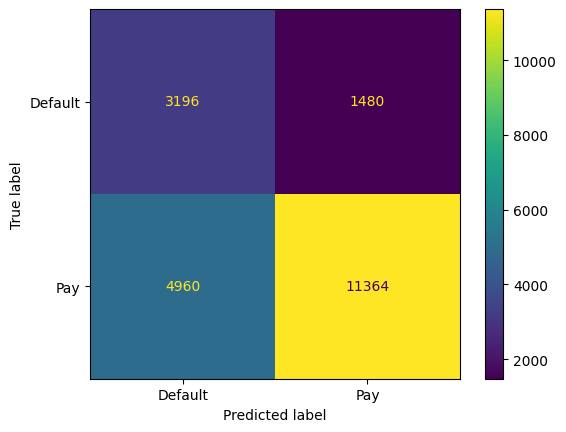

In [40]:
val_pca = calibration_metrics(X_train,y_train,show_plots=True,calibrate_model=False, n_components=20, learning_rate=0.01, n_iter=20000, lambda_param=50, thres = 0.5,fit_pca=True,class_weight=True)

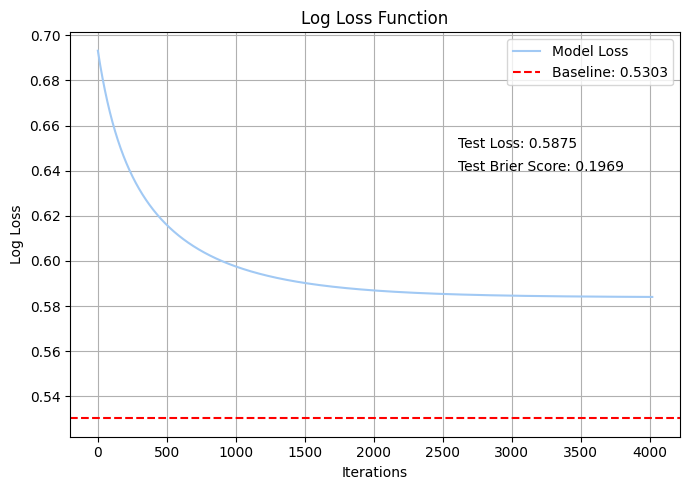

In [41]:
val_pca.plot_loss_function(y_train=y_train)


As we have seen before, Log Los and Brier score are higher than their respective baseline. Model is also overconfident as it tends to assign higher probability values than the actual likelihood and it is below the diagonal. As mentioned before, it is a consequence of implementing class weights, which are also necesary to identify the positive class despite risking lower initial calibration. Let us calibrate the output probabilities from this same model.

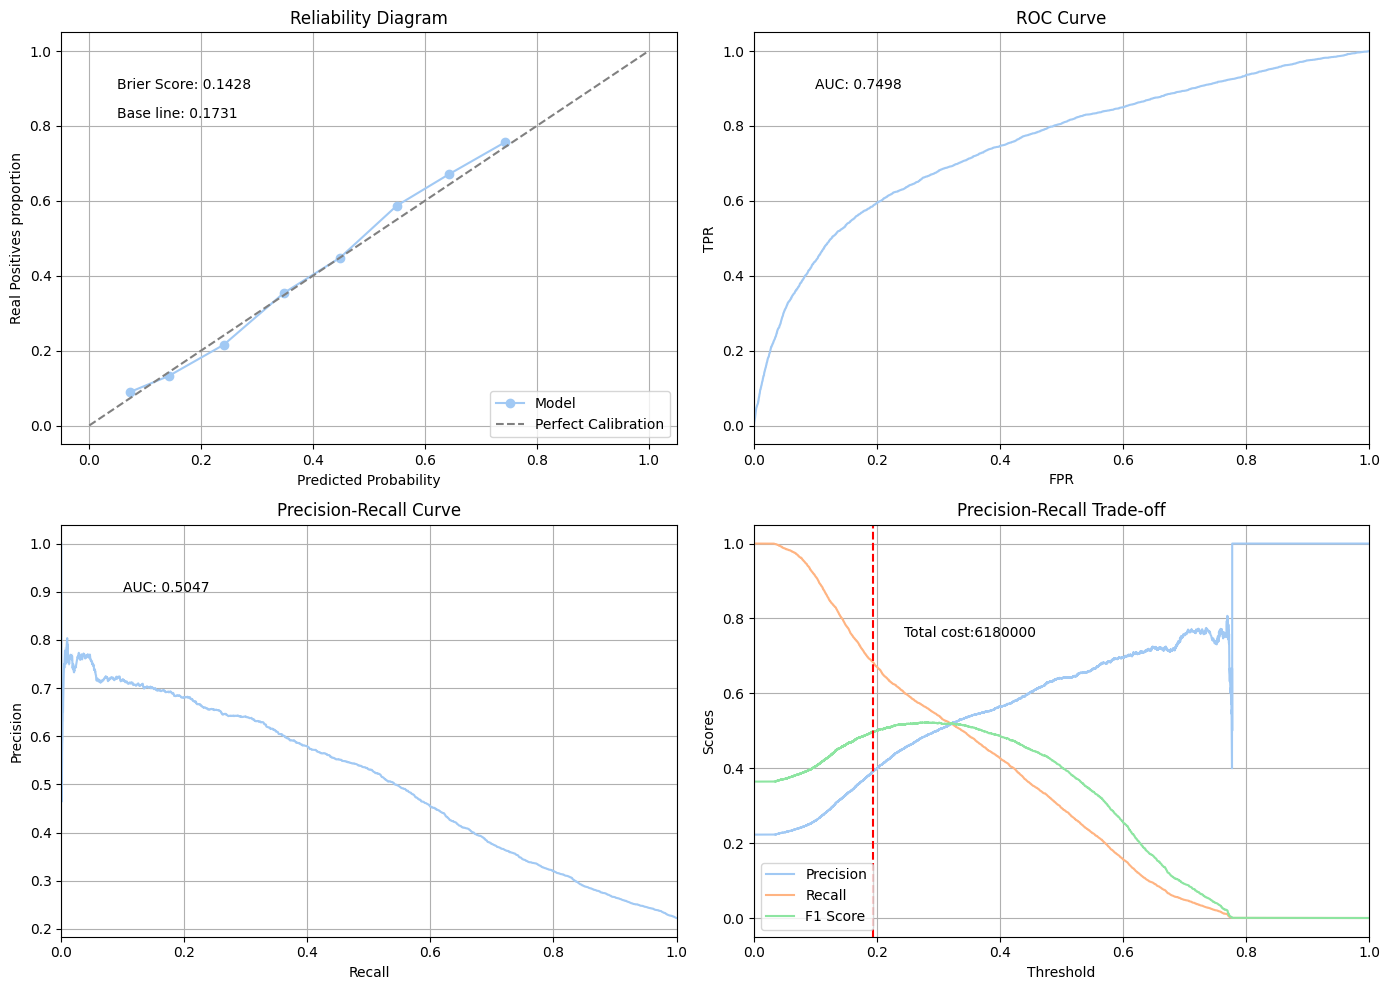

Loss: 0.4518
Accuracy:0.6933
Precision: 0.3919
Recall: 0.6835
F1-Score: 0.4981

Confusion Matrix:


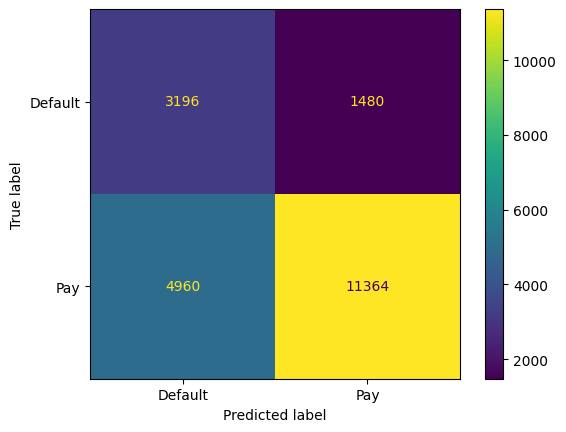

In [42]:
val_pca_calibrated = calibration_metrics(X_train,y_train,show_plots=True,calibrate_model=True, n_components=20, learning_rate=0.01, n_iter=20000, lambda_param=50, thres = 0.5,fit_pca=True,class_weight=True)


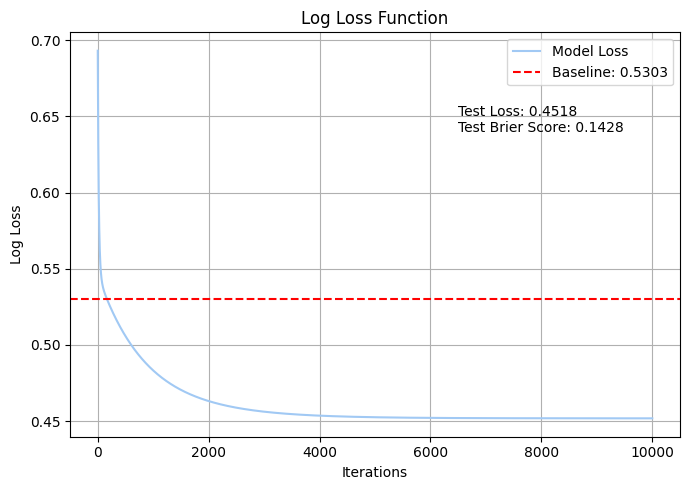

In [43]:
val_pca_calibrated.plot_loss_function(y_train=y_train)


After calibrating three facts are noticeable:
- First the model is consistently close or almost over the diagonal line, which means that probabilities tend to converge to the actual likelihood.
- Brier score and Log loss are significantly lower than those of the not calibrated model, even lower than their prevalence value, Meaning overall errors in prediction not only are lower, but also outperforms always predicting the prior probability by a 17.37%.
- Threshold has changed to a more representative value.
- Rest of metrics remain untouched. As AUC, accuracy and confusion matrix scores are based in thresholds and sorting remains the same after calibration, these values remain the same with the new optimum thresholds.

Next the same operation will be repeated with the original dataset.

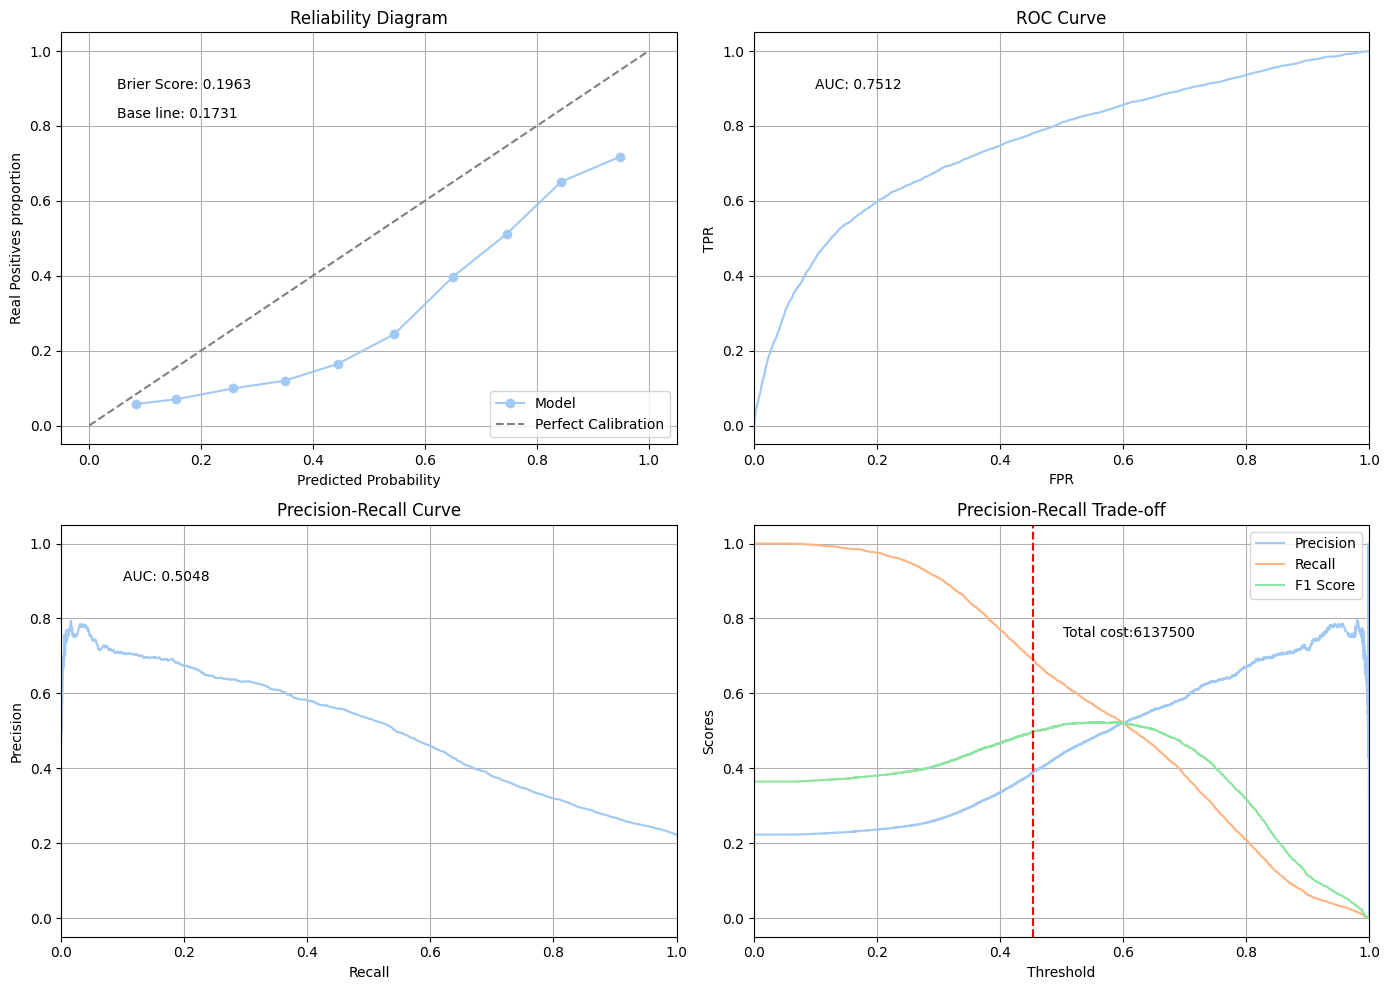

Loss: 0.5851
Accuracy:0.6898
Precision: 0.3894
Recall: 0.6920
F1-Score: 0.4983

Confusion Matrix:


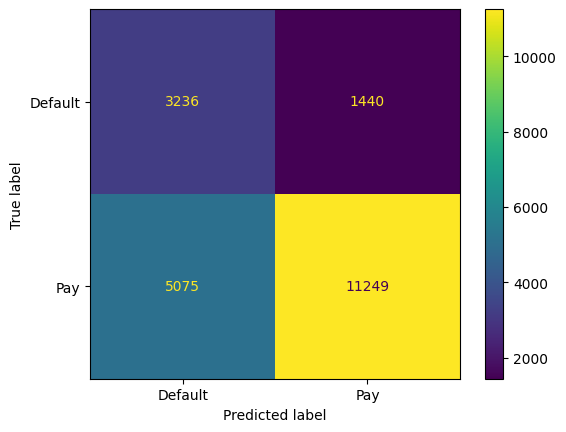

In [44]:
val_original = calibration_metrics(X_train,y_train,show_plots=True, n_components=None,calibrate_model=False, learning_rate=0.01, n_iter=20000, lambda_param=1,class_weight=True,fit_pca=False)

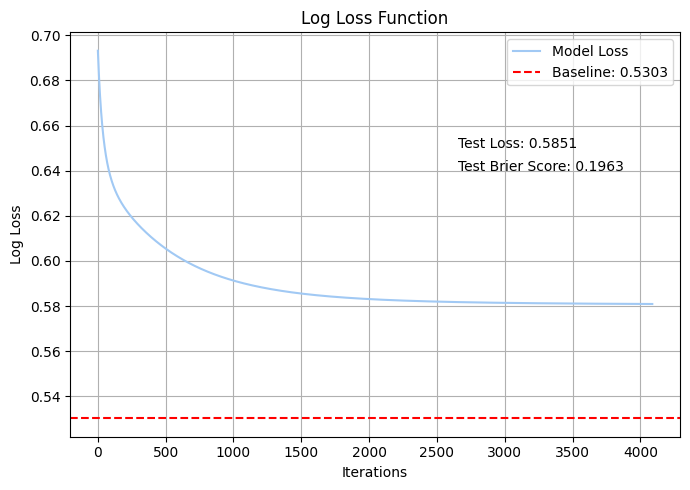

In [45]:
val_original.plot_loss_function(y_train=y_train)


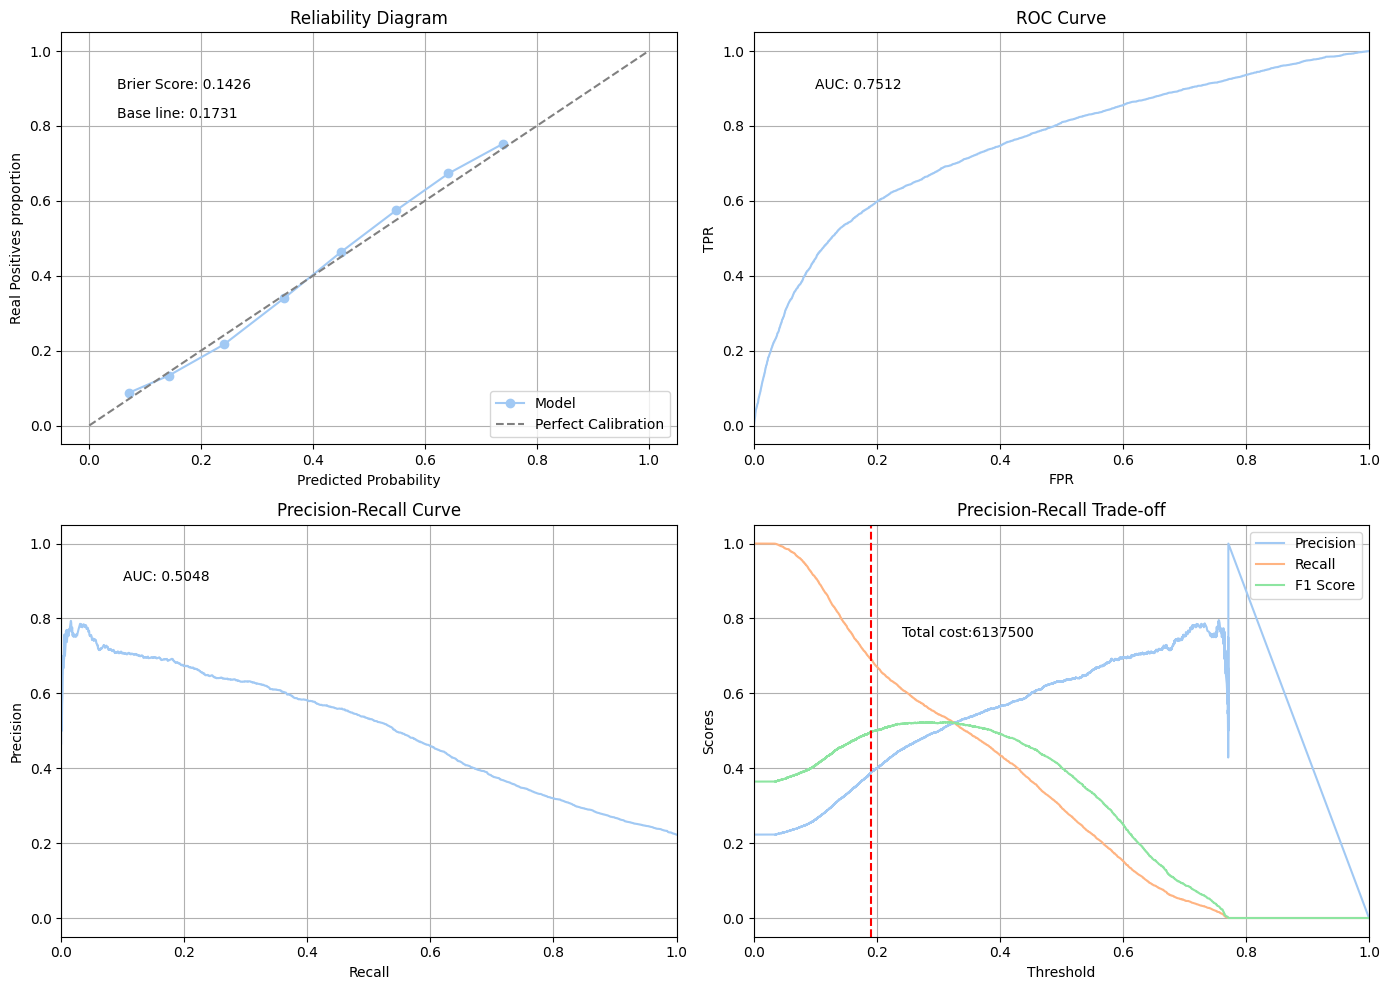

Loss: 0.4512
Accuracy:0.6898
Precision: 0.3894
Recall: 0.6920
F1-Score: 0.4983

Confusion Matrix:


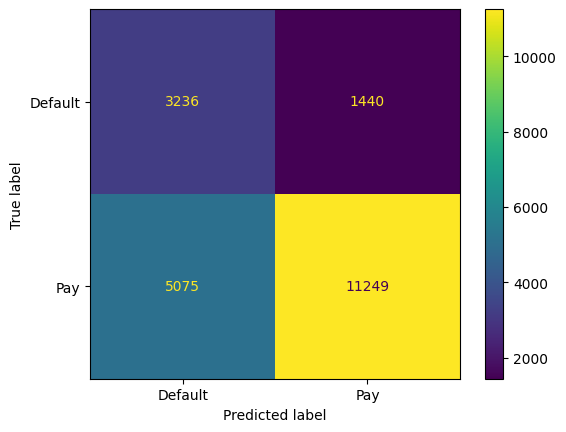

In [46]:
val_original_calibrated = calibration_metrics(X_train,y_train,show_plots=True, n_components=None,calibrate_model=True, learning_rate=0.01, n_iter=20000, lambda_param=1,class_weight=True,fit_pca=False)

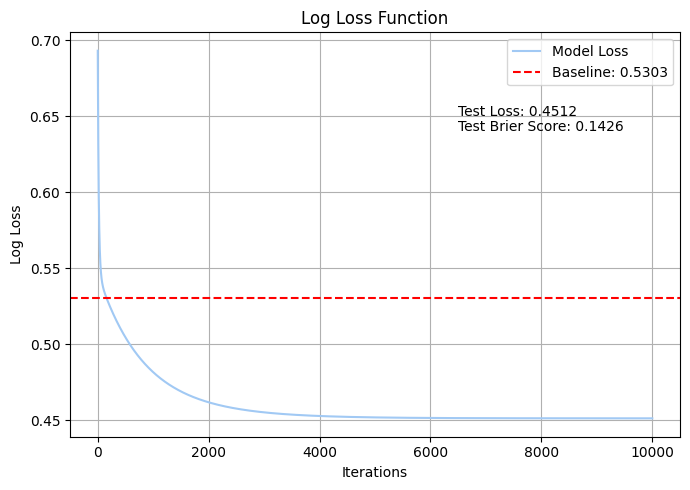

In [47]:
val_original_calibrated.plot_loss_function(y_train=y_train)

Both models have similar general non threshold dependend metrics such as AUC values but the original dataset comes on top. Although the minimum cost varies because the PCA projected model has a higher recall but lower precission so the model selection in this case is based on business needs. Minimum cost is the main metric for the model as fit is almost identical and computational cost are also similar

On the next chapter we will open our black boxes to see how they predict a defaulting client and which variables or components are most important in the model and which are more trivial.

# Model Interpretation

This chapter aims to understand the model and how it learns from the data and which variables/components have a bigger impact in it. First we will perform this analysis from the PCA and then for the original data

## PCA Loadings and explained Variance

A Principal Component analysis aims to find the components in the data that maximize the total explained variance in the observations where each component is a linear combination of the original variables and are ordered from higher to lower variance. The goal is to reduce dimensionality by choosing an arbitrarily number of components while retaining the highest amount of information.

It is important to note that higher variance in a component does not always equal to higher predictive value. A component can have the highest explained variance and at the same not represent an important feature to predict the target class or value. On the contrary, a low variance component can be crutial to the model predictions. Therefore, the chosen components should be those that the model give most importance to (how importance is meassured is to be explained later on this chapter) and not necesarily those with higher explained variance.

The following column plot shows the explained variance of each Principal component. The component 1 has an explained variance of 37.8% and component 2 of 12%. By selecting the first 14 Principal Components a 90% of the data information would be kept, efectively reducing the original dataset of 35 variables down to 14 projected components while retaining 90% of the variance.

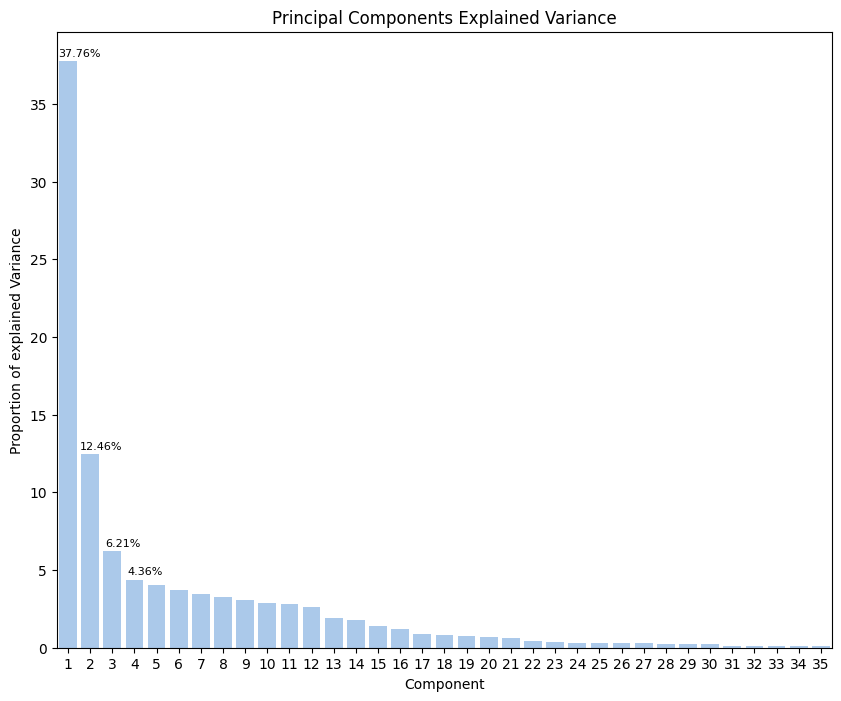

In [48]:
pca_scratch, log_reg_scratch, y_pred_scratch, y_pred_proba_scratch = scratch_model_pipeline(X_train, X_train, y_train,20,0.01,20000,50,class_weight=False)
loadings = pca_scratch.get_loadings(X.columns)

plt.figure(figsize=(10, 8))

ax = sns.barplot(x= range(1,36) ,y = pca_scratch.explained_variance*100)


for i, val in enumerate(pca_scratch.explained_variance * 100):
    if i < 4:
        ax.text(i+0.5, val + 0.2, f'{val:.2f}%', ha='center', va='bottom', fontsize=8)


plt.title('Principal Components Explained Variance')
plt.xlabel('Component')
plt.ylabel('Proportion of explained Variance')

plt.show()

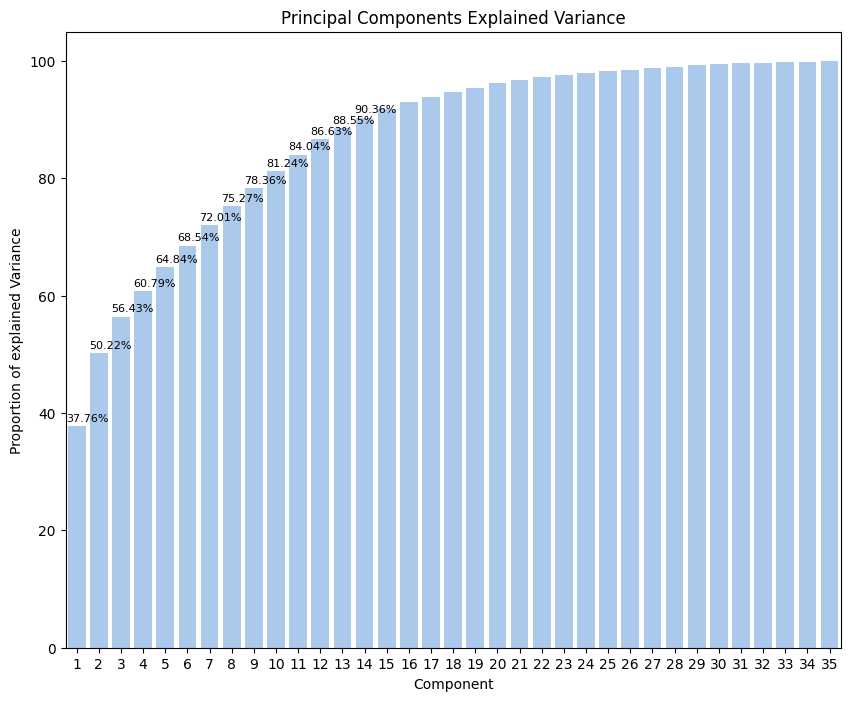

In [49]:
plt.figure(figsize=(10, 8))

ax = sns.barplot(x= range(1,36) ,y = pca_scratch.cum_variance*100)

for i, val in enumerate(pca_scratch.cum_variance * 100):
    if i < 14:
        ax.text(i+0.5, val + 0.5, f'{val:.2f}%', ha='center', va='bottom', fontsize=8)


plt.title('Principal Components Explained Variance')
plt.xlabel('Component')
plt.ylabel('Proportion of explained Variance')

plt.show()

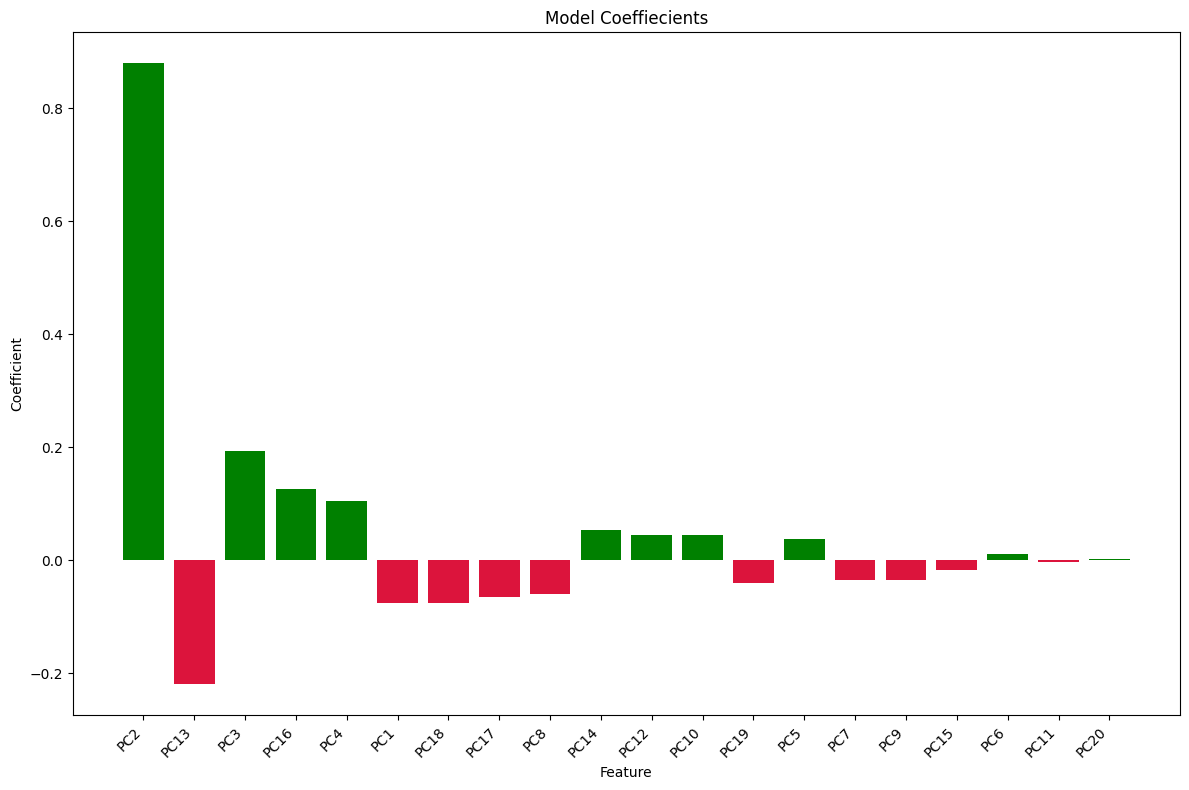

In [50]:

def plot_model_coefs(columns,coef):

    PC_coef = pd.DataFrame({'Feature':columns,
                            'Coeficient': coef,
                            'Importance': np.abs(coef)})
    PC_coef = PC_coef.sort_values('Importance',ascending=False)
    color = ['green' if x > 0 else 'crimson' for x in PC_coef['Coeficient']]

    plt.figure(figsize=(12, 8))

    plt.bar(PC_coef['Feature'], PC_coef['Coeficient'],color=color)

    plt.title('Model Coeffiecients')
    plt.xlabel('Feature')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Coefficient')
    plt.tight_layout()
    plt.show()

plot_model_coefs(loadings.columns,log_reg_scratch.w)

Principal Component 2 is the most important component in the PCA projected models as it is the feature with highest absolute weight or coefficient value. It is also a risk factor, meaning that the higher this component is, the higher is the probability of default given the model.

The remaining components have certain importance, but show coefficients below 0.2 in absolute value with alternating signs that partially offset their combined contribution. by other component combinations with positive and negative risk factor. Therefore, it is likely that this model relies most heavily in PC2 when predicting a probability. Let us see what combination of variables are in this component.

In [51]:

def get_pc_loadings_df(component):

    loading = pd.DataFrame(loadings[f'PC{component}'])
    loading.columns = ['loadings']
    loading['abs_loadings'] = loading['loadings'].abs()
    loading = loading.sort_values(by='abs_loadings',ascending=False)
    loading['prop_loading'] = (loading['abs_loadings']/loading['abs_loadings'].sum())*100
    return loading

def show_pc_loadings(component):

    loading = get_pc_loadings_df(component)

    plt.figure(figsize=(8, 6))

    sns.barplot(x='prop_loading', y= loading.index,data=loading,hue=loading.index, palette='Reds_r')
    plt.title(f'Principal Component {component}')
    plt.xlabel('Feature importance')
    plt.ylabel('')

    plt.show()

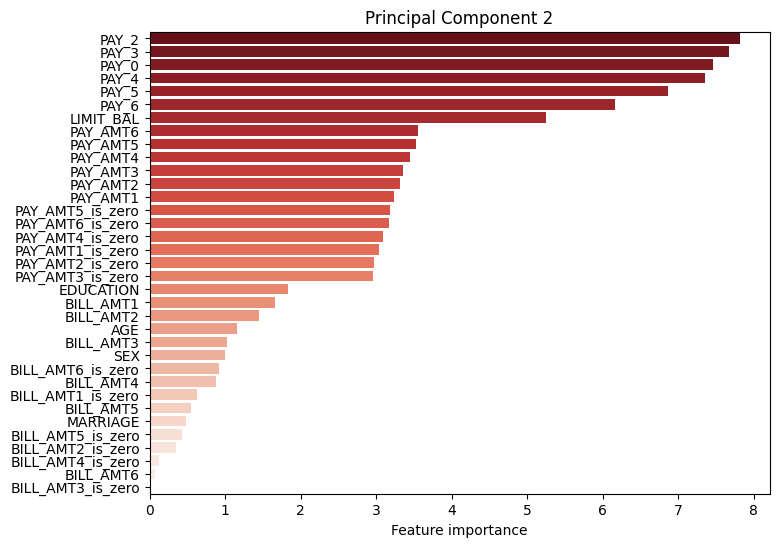

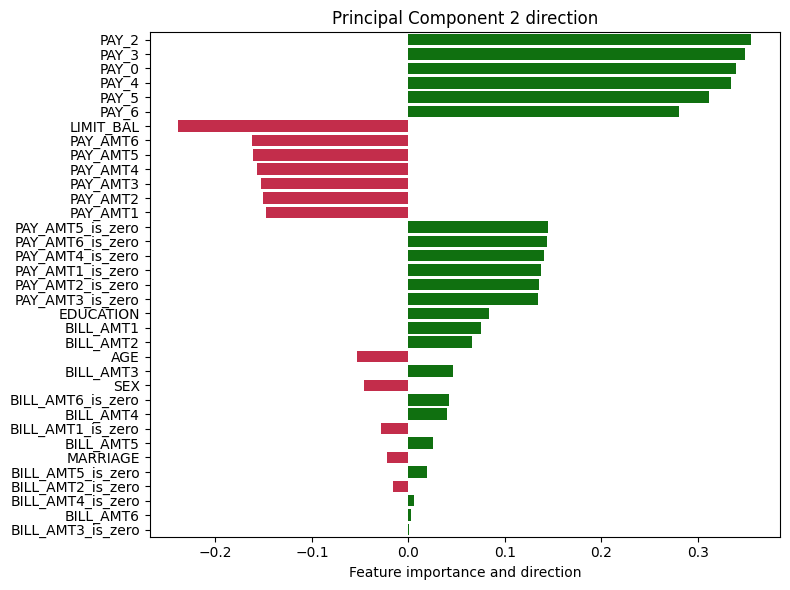

In [52]:
def show_pc_direction(component):

    loading = get_pc_loadings_df(component)

    color = ['green' if x > 0 else 'crimson' for x in loading['loadings']]


    plt.figure(figsize=(8, 6))

    sns.barplot(x=loading['loadings'], y= loading.index, hue= loading.index,palette= color )
    plt.title(f'Principal Component {component} direction')
    plt.xlabel('Feature importance and direction')
    plt.ylabel('')
    plt.tight_layout()

    plt.show()

show_pc_loadings(2)
show_pc_direction(2)

Plots above shows the variable composition of PC2 ordered by importance measured by the absolute value of each value in the component vector. The higher the absolute value is, the higher importance the variable has within the component.

First graph shows the absolute values of the loadings in PC2 and the graph below also shows the direction of this variable. Green bars are positive values and are also risk factors, such as payment delays or not paying any amount a given month. Higher Balance limit seems to be a protective factor to this risk, although this might be a confusion variable as banks tend to put higher limits to customers that have a favourable history of payment but not the other way around. Higher pay amounts are also a protective factors to the model given this component unless that pay amount is equal to zero. Other variables such as sex and education seem to be less informative than the stated above.

But is there a way to summarize all these variables and directions? What is this Principal Component and what does represent exactly? Unfortunately, one of the biggest downsides of PCA is possible loss interpretacion in return of reduced dimensionality. Imagine being in a party in a villa with some of your best friends and family and you decide to take a picture of the moment. The picture can not record any sort of smell, music or movement there actually is in the party, but it takes just enough information of the moment to remember or imagine. The party represents the original dataset, and the projected dataset is the picture taken. It is not possible to know what is not in the picture, but one can subjectively make assumptions of it.

PC2 include variables such as Pay Status, Balance limit, Pay amount and its flag among the top ranked loadings. These variables have something in common and are a decisive factor for credit risk. A useful interpretation is that these variables are related to customers past behaviour: if client payment was delayed or did not met payment a certain month, this risk tends to increase. On the contrary, if the bank conceded a higher balance limit to a client (presumably due to a positive credit history) or pays higher amounts the risk factor decreases. Therefore a valid interpretation would be that PC2 is mostly about credit history factor.

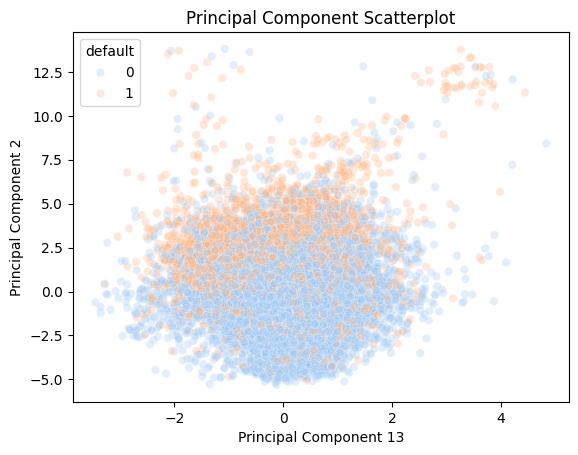

In [53]:
def pca_scatterplot(data,*args):
  pca,PC_data_2,_ = pca_data(data, data,35)

  if len(args)>2:
      print('ValueError')
  elif len(args)==1:
    args = [args[0],args[0]]
  sns.scatterplot(x=PC_data_2[:,args[0]-1],y=PC_data_2[:,args[1]-1],hue= y_train, alpha=0.3)
  plt.title('Principal Component Scatterplot')
  plt.xlabel(f'Principal Component {args[0]}')
  plt.ylabel(f'Principal Component {args[1]}')

  plt.show()

pca_scatterplot(X_train,13,2)

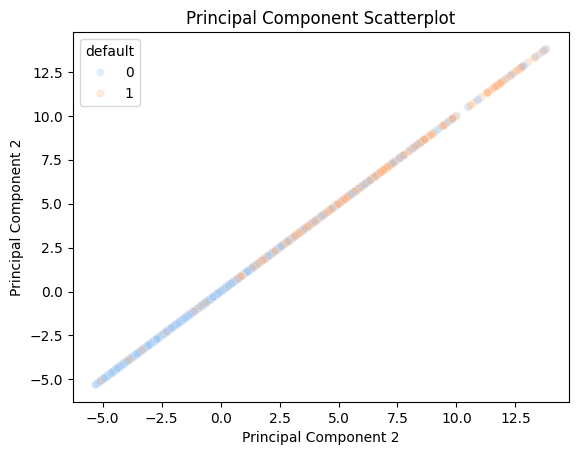

In [54]:
pca_scatterplot(X_train,2,2)

Above scatterplots visually shows that both classes are quite differentiated in PC2. Higher values of this component tend to be in the positive class and lower values in the negative class.

In [55]:
_,log_reg_original,y_pred_original,y_pred_proba_original = scratch_model_pipeline(X_train,X_train,y_train=y_train, n_components=None, learning_rate=0.01, n_iter=20000, lambda_param=10,fit_pca=False)

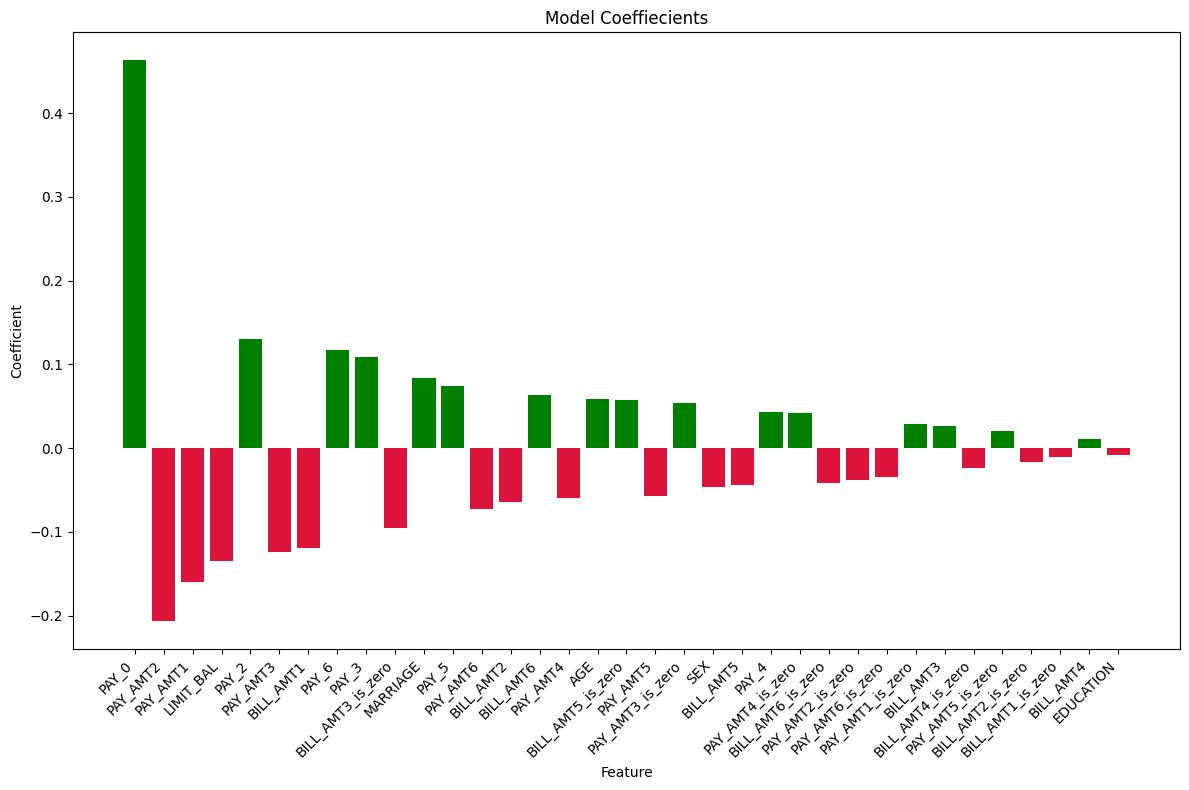

In [56]:
plot_model_coefs(X_train.columns,log_reg_original.w)

Original variables that are important in PC2 have also high absolute values in the model weights and provide similiar signs in each one. Pay status, Pay amount, Balance limit and now, Bill amounts are decisive for the model, although PAY_0 is the highest one, meaning that delaying in payment from the beginning is likely a one way ticket to default.

# Model Final Test

In [57]:
def test_model(X_train,X_test, y_train,calibrate_model=True, n_components=20, learning_rate=0.01, n_iter=20000, lambda_param=50, thres = 0.5,fit_pca=True,class_weight=True):
    validation = calibration_metrics(X_train=X_train,y_train=y_train,calibrate_model=calibrate_model, n_components=n_components, learning_rate=learning_rate, n_iter=n_iter, lambda_param=lambda_param, thres = thres,fit_pca=fit_pca,class_weight=class_weight)


    pca, log_reg, y_pred, y_pred_proba = scratch_model_pipeline(X_train=X_train,X_test=X_test,y_train=y_train, n_components=n_components, learning_rate=learning_rate, n_iter=n_iter, lambda_param=lambda_param, thres = thres,fit_pca=fit_pca,class_weight=class_weight)

    if calibrate_model:
        y_pred_proba_calibrated = validation.model.predict_proba(y_pred_proba.reshape(-1,1))
        test =  ClassifierEvaluation(y_pred_proba_calibrated,y_test,validation.model)

    else:
        test =  ClassifierEvaluation(y_pred_proba,y_test,log_reg)

    test.classification_scores()
    test.evaluate_scores()
    test.calculate_threshold(500,2500)
    return test


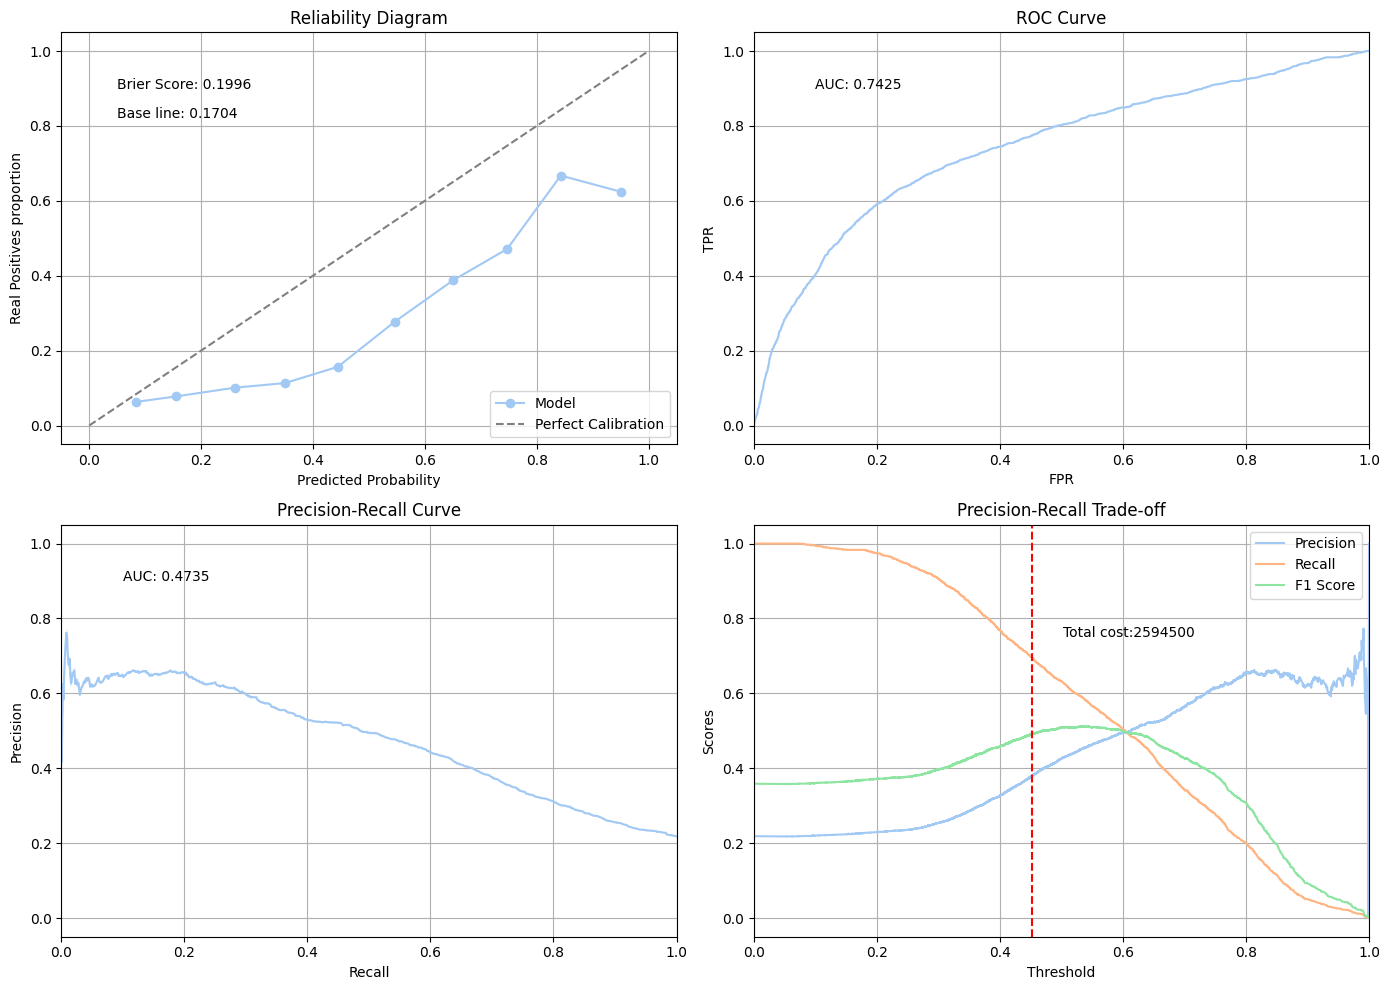

In [58]:
test = test_model(X_train,X_test, y_train,calibrate_model=False, n_components=20, learning_rate=0.01, n_iter=20000, lambda_param=50, thres = 0.5,fit_pca=True,class_weight=True)
test.plot_scores(decision=test.best_threshold)

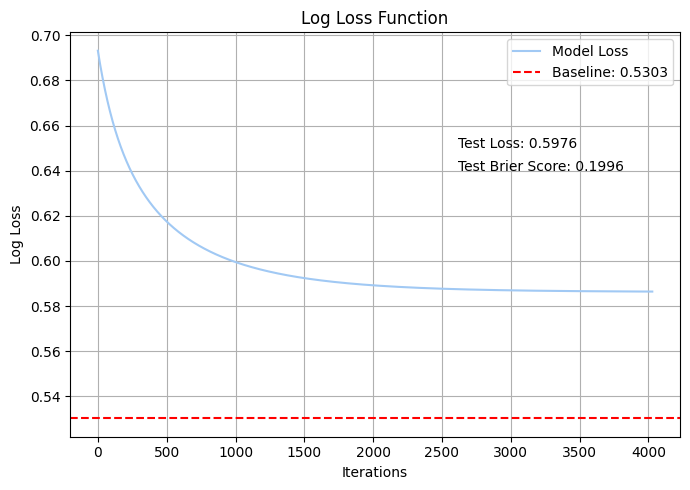

In [59]:
test.plot_loss_function(y_train=y_train)

In [60]:
test = test_model(X_train,X_test, y_train,calibrate_model=True, n_components=20, learning_rate=0.01, n_iter=20000, lambda_param=50, thres = 0.5,fit_pca=True,class_weight=True)

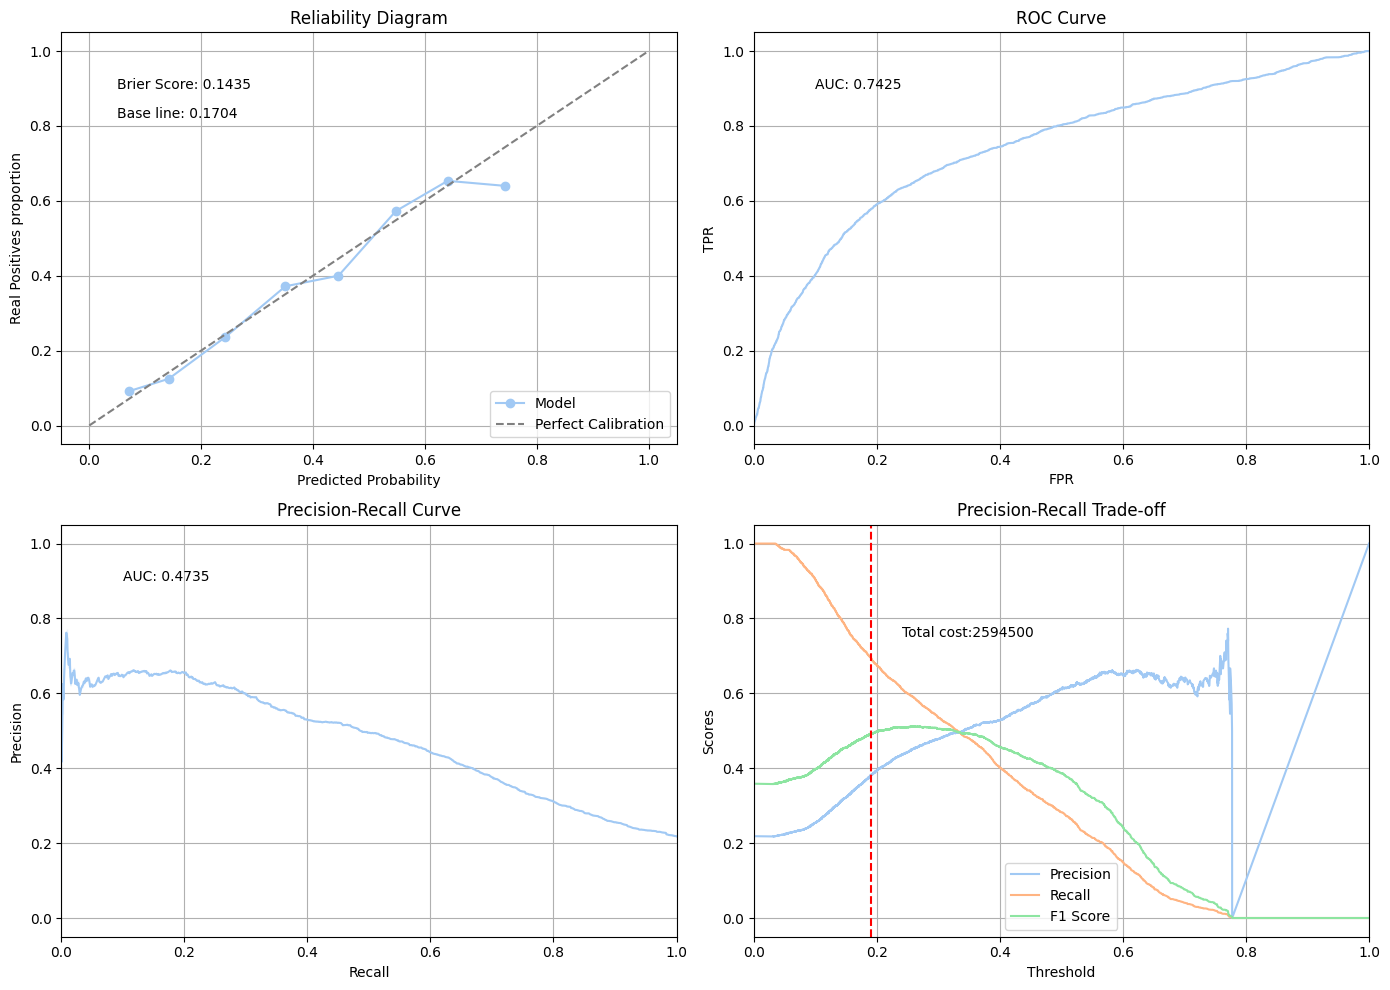

In [61]:
test.plot_scores(decision=test.best_threshold)

In [62]:
test_original = test_model(X_train,X_test,y_train, n_components=None,calibrate_model=True, learning_rate=0.01, n_iter=20000, lambda_param=1,class_weight=True,fit_pca=False)

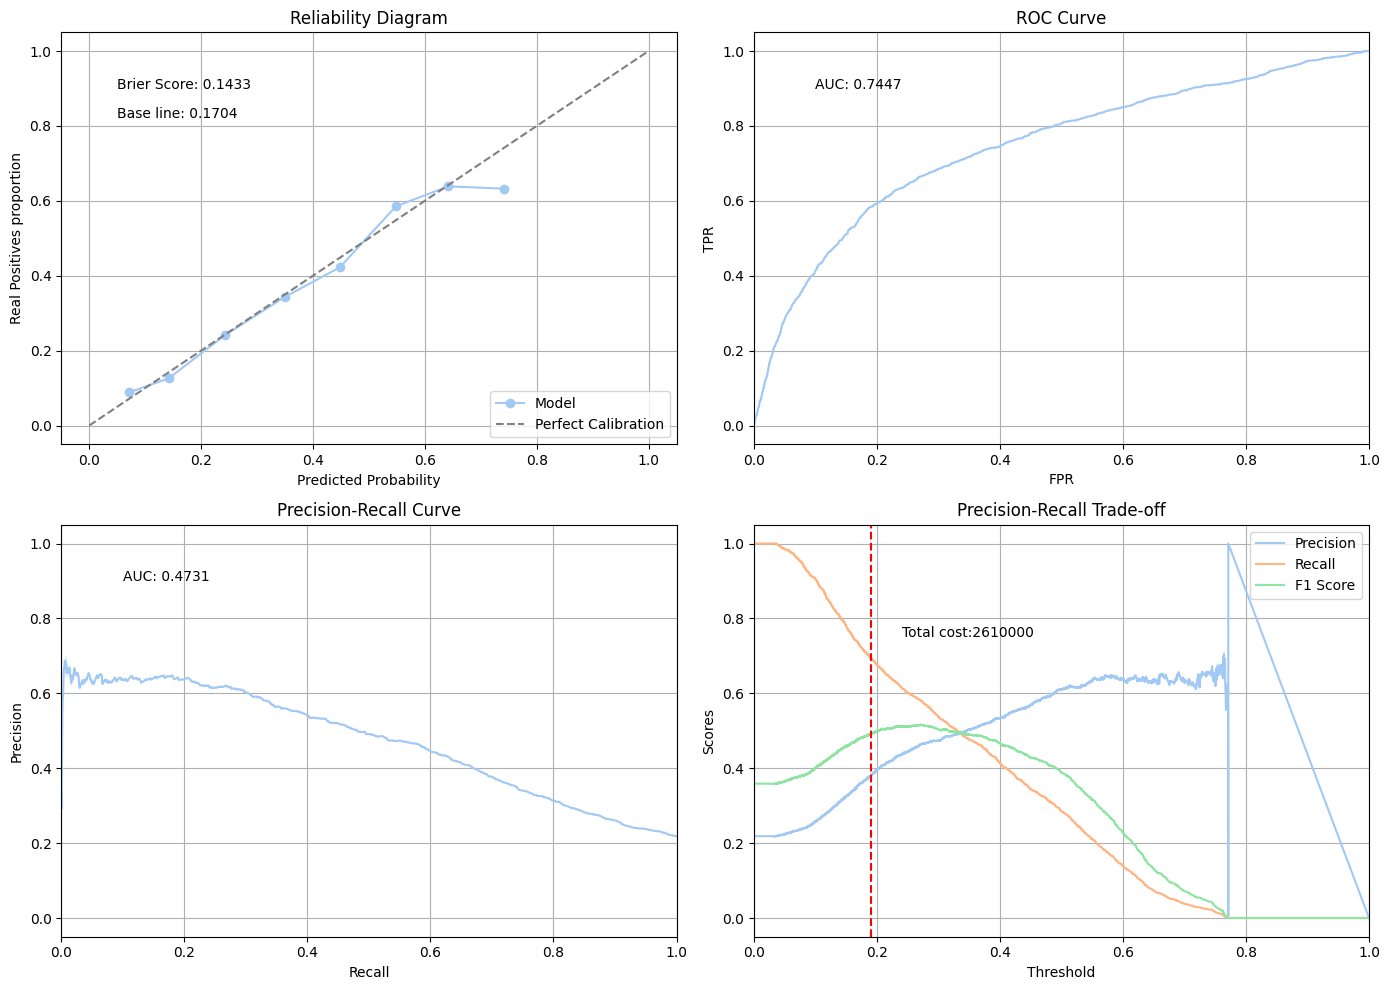

In [63]:
test_original.plot_scores(decision=test.best_threshold)

# Conclusions

In this end to end project we have fit a credit Risk model applied to a Credit Default Dataset. This data has to be preprocesed and transformed accordingly as it some features needed to be scaled and log-transformed data to balance distributions and prevent high scaling differences between variables. Multicollinearity also was adressed, although it was not a great issue for the original data model as the fit was similar than that of the PCA projected dataset. Speaking of which, a Principal Component analysis was implemented by scratch using covariance matrix and Jacobi method. Although the presented method differs from Scikit learn Singular Value Decomposition one, results were proven almost equall using L2 norm to compare the explained variance output and components. Logistic Regression was also implemented from scratch and compared with Scikit Learn Benchmark where outputs where also equal.

After asserting both algorithms do work as intended it was time to implement an evaluation method. First model fit and class discrimination was tested using Cross Entropy funtion and Brier Score. It was shown that the model had an underfitting issue as both scores where over their respective prevalence value. Calibration was also tested visually through a Reliability Diagram where it was shown that the model was overconfident.

Next metrics where threshold dependent and proved that model could still be useful for the business even if it underfits. Although accuracy or ROC AUC are not a reliable source for this problem, they presented fair values. PR AUC score showed that the model could indeed discriminate the positive class and fairly predict a possible default.

Threshold selection was made by business given costs of errors. Knowing that defaults come with direct costs for a loaner and are normally higher than the opportunity cost of not lending to a good customer, it was decided that False Negatives represents a higher threat for the business than False Positives, therefore, Recall was the most important metric to look at.

Cross Validation was the next goal. After knowing the model, its limitations and potential it was time to see if evaluations was consistent for different validation sets and also which hypermarameters are best combination. Range of parameters was lower than advisable as computational cost was high and the project goal is merely for learning purpose. After a sample of 20 different combinations, it was determined that there was no significative difference between models as metrics differences were very low. Therefore, two configurations where preselected first by PR AUC score and then by training time, one that fits the PCA and the other with original variables.

Second phase of selection was to compare this two model using the previous evaluation metrics and by minimum costs for the business. The original variables model came slightly on top as dimensionality was not high enough to benefit from a PCA in terms of model metric performance.

In any case, both models where interpreted. PC2 was the most important component which was named a client history component as the most important features where those that determine a client payment history such as balance limit, payment history and delays on peyment. Original variables model did also weighted similarly these variables and calculated the probability of default relying in this metrics. It was also shown that PC2 was the variable responsible for more than 90% of the model performance.

Although model selection should depend on different needs (either interpretation, computational costs, metrics performance, etc) the most convincing model is the one fitted with original data as it provides the lowest cost for the given example, which, are set to purely arbitrary values given the purpose of this notebook is purely educational. Even though the projected dataset could effectively reduce the dimensionality of the data, it could not provide higher value to the business as all metrics where similar and so was computational cost.

Test evaluation showed there was no overfitting in the models and all metrics where similar to those in training and validation sets. Original dataset was still on outperforming the projected data regarding scores, metrics and minimum cost.

## Bibliography



https://corporatefinanceinstitute.com/resources/career-map/sell-side/risk-management/expected-loss-definition-calculation-importance/